# Transformer Diffusion Model Validation

## Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.flop_counter import FlopCounterMode
from IPython.display import display

from implied_volatility_diffusion import (
    DiffusionModel,
    GridTransformer,
    ReverseDiffusion,
    SurfaceNormalizer,
    UnifiedGrid,
    VPNoiseScheduler,
    check_iv_surface_arbitrage,
    repair_iv_surface,
    volgan_generative_repair_settings,
)


def _select_device():
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


DEVICE = _select_device()
REPO_ROOT = Path.cwd().resolve()
for _candidate in (REPO_ROOT, *REPO_ROOT.parents):
    if (_candidate / "config").is_dir() and (_candidate / "src").is_dir():
        REPO_ROOT = _candidate
        break
else:
    raise RuntimeError("could not find repository root (expected config/ and src/)")
CFG_DIR = REPO_ROOT / "config"
import sys

if str(REPO_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "notebooks"))
from plot_style import (
    DIFF_CMAP,
    SURF_CMAP,
    TENOR_COLORS,
    apply_theme,
    rc_context,
    style_2d_axes,
    style_3d_axes,
)

PLOT_THEME = "plotnine"
apply_theme(PLOT_THEME)

DATASET_ROOT = REPO_ROOT / "data" / "processed" / "forecasting_dataset"
CHECKPOINT_DIR = REPO_ROOT / "data" / "processed" / "checkpoints"
CHECKPOINT_PATH = CHECKPOINT_DIR / "transformer_mse.pt"
CONFIG_PATH = CHECKPOINT_DIR / "training_config.json"

GRID = UnifiedGrid.load(CFG_DIR / "unified_iv_grid.yaml")

if not (DATASET_ROOT / "manifest.json").exists():
    raise FileNotFoundError(f"missing {DATASET_ROOT / 'manifest.json'}; run notebooks/data/data_pipeline.ipynb first")
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"missing {CHECKPOINT_PATH}; train the transformer model first")

print(f"compute device: {DEVICE}")
print(f"unified grid: {GRID.shape}")

compute device: mps
unified grid: (41, 40)


## Validation Inputs

In [2]:
PATH_TYPES = ("historical", "sabr", "heston")
TENOR_SLICES_PER_SURFACE = 3
DDIM_STEPS = 200
ARB_DIAG_TOL = 1e-6
IV_FLOOR_SAMPLE = 1e-4
ARB_ACCEPT_TOL = 1e-4
GENERATED_ARB_TOL = ARB_ACCEPT_TOL
APPLY_SURFACE_REPAIR = True
FORECAST_REPAIR_SETTINGS = volgan_generative_repair_settings(
    tol=GENERATED_ARB_TOL,
    iv_floor=IV_FLOOR_SAMPLE,
)
SAMPLER_CLIP_Z = (-4.0, 4.0)

SOURCE_LABELS = {0: "historical", 1: "heston", 2: "sabr"}
PATH_TYPE_TO_SRC_ID = {"historical": 0, "heston": 1, "sabr": 2}
unknown_paths = [p for p in PATH_TYPES if p not in PATH_TYPE_TO_SRC_ID]
if unknown_paths:
    raise ValueError(f"Unknown path types in PATH_TYPES: {unknown_paths}")

run_config = json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}
VALIDATION_SEED = int(run_config.get("seed", 42))
GENERATION_SEEDS = [VALIDATION_SEED + 9000 + i for i in range(len(PATH_TYPES))]

tenor_idx = np.linspace(0, GRID.shape[1] - 1, TENOR_SLICES_PER_SURFACE).round().astype(int)
tenor_idx = np.unique(tenor_idx)
if tenor_idx.size != TENOR_SLICES_PER_SURFACE:
    raise RuntimeError(f"Expected exactly {TENOR_SLICES_PER_SURFACE} unique tenor slices, got {tenor_idx.size}.")

validation_inputs_df = pd.DataFrame(
    [
        {"input": "checkpoint", "value": str(CHECKPOINT_PATH.relative_to(REPO_ROOT))},
        {"input": "training config", "value": str(CONFIG_PATH.relative_to(REPO_ROOT))},
        {"input": "dataset", "value": str(DATASET_ROOT.relative_to(REPO_ROOT))},
        {"input": "validation instances", "value": list(PATH_TYPES)},
        {"input": "tenors shown per surface", "value": TENOR_SLICES_PER_SURFACE},
        {"input": "selected tenor years", "value": np.round(GRID.tau[tenor_idx], 4).tolist()},
        {"input": "DDIM steps", "value": DDIM_STEPS},
        {"input": "base generation seeds", "value": GENERATION_SEEDS},
        {"input": "strict diagnostic tol", "value": ARB_DIAG_TOL},
        {"input": "soft acceptance tol", "value": ARB_ACCEPT_TOL},
        {"input": "required forecast arbitrage tol", "value": GENERATED_ARB_TOL},
        {"input": "VolGAN surface repair", "value": APPLY_SURFACE_REPAIR},
    ]
)
display(validation_inputs_df)

,input,value
0,checkpoint,data/processed/checkpoints/transformer_mse.pt
1,training config,data/processed/checkpoints/training_config.json
2,dataset,data/processed/forecasting_dataset
3,validation instances,"[historical, sabr, heston]"
4,tenors shown per surface,3
5,selected tenor years,"[0.05, 1.05, 2.0]"
6,DDIM steps,200
7,base generation seeds,"[9042, 9043, 9044]"
8,strict diagnostic tol,0.000001
9,soft acceptance tol,0.0001


## Load validation pairs and checkpoint

After the model is loaded, parameter count, memory footprint (MB), single-forward GFLOPs, and total DDIM-sampling GFLOPs are reported below.

In [3]:
manifest = json.loads((DATASET_ROOT / "manifest.json").read_text())
normalizer = SurfaceNormalizer.load(DATASET_ROOT / "normalizer.npz")
assert tuple(normalizer.grid_shape) == tuple(GRID.shape), (
    f"normalizer grid {normalizer.grid_shape} != unified grid {GRID.shape}"
)

VAL_DIR = DATASET_ROOT / "validation"
val_pair_curr = np.load(VAL_DIR / "pair_curr.npy").astype(np.float32)
val_pair_next = np.load(VAL_DIR / "pair_next.npy").astype(np.float32)
val_sources = np.load(VAL_DIR / "pair_sources.npy")

pair_curr_by_src = {}
pair_next_by_src = {}
for _src_id in [0, 1, 2]:
    _mask = val_sources == _src_id
    pair_curr_by_src[_src_id] = val_pair_curr[_mask]
    pair_next_by_src[_src_id] = val_pair_next[_mask]

val_hist_curr_dates = pd.DatetimeIndex(np.load(VAL_DIR / "historical_curr_dates.npy"))
val_hist_next_dates = pd.DatetimeIndex(np.load(VAL_DIR / "historical_next_dates.npy"))
val_heston_paths = np.load(VAL_DIR / "heston_path.npy")
val_heston_steps = np.load(VAL_DIR / "heston_step.npy")
val_sabr_paths = np.load(VAL_DIR / "sabr_path.npy")
val_sabr_steps = np.load(VAL_DIR / "sabr_step.npy")

n_pairs_by_src = {k: int(v.shape[0]) for k, v in pair_curr_by_src.items()}
print(
    f"validation pairs by source -- historical={n_pairs_by_src[0]}  "
    f"heston={n_pairs_by_src[1]}  sabr={n_pairs_by_src[2]}"
    f"  (total={sum(n_pairs_by_src.values())})"
)

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
SCHEDULER_TIMESTEPS = int(checkpoint.get("scheduler_timesteps", run_config.get("scheduler_timesteps", 400)))
_transformer_kw = checkpoint.get("transformer_kwargs") or run_config.get("transformer_kwargs")
SPOT_REF = float(checkpoint.get("spot_ref", run_config.get("spot_ref", 100.0)))
RATE_REF = float(checkpoint.get("rate_ref", run_config.get("rate_ref", 0.03)))

if _transformer_kw:
    backbone_kw = dict(_transformer_kw)
    backbone = GridTransformer(**backbone_kw)
    backbone_artifact = "GridTransformer kwargs"
    prediction_type = checkpoint.get("prediction_type", None)
else:
    raise RuntimeError("Checkpoint missing `transformer_kwargs` in checkpoint/run config.")

cond_channels = int(backbone_kw.get("cond_channels", 0))
if cond_channels < 1:
    raise RuntimeError(
        "Loaded checkpoint is unconditional (cond_channels=0). Re-train the transformer model with conditional inputs."
    )

scheduler = VPNoiseScheduler(timesteps=SCHEDULER_TIMESTEPS, beta_schedule="cosine")

_vqvae_kw = checkpoint.get("vqvae_kwargs") or run_config.get("vqvae_kwargs")
_use_vqvae = bool(checkpoint.get("use_magvit_vqvae", run_config.get("use_magvit_vqvae", _vqvae_kw is not None)))

if _use_vqvae and _vqvae_kw:
    from implied_volatility_diffusion import MAGViTv2VQVAE
    _vq = MAGViTv2VQVAE(**{k: tuple(v) if isinstance(v, list) else v for k, v in _vqvae_kw.items()})
    print(
        f"VQ-VAE detected: latent_channels={_vq.latent_channels}, "
        f"codebook_size={_vq.codebook_size}, num_downsample={_vq.num_downsample}"
    )
elif _use_vqvae:
    raise RuntimeError(
        "Checkpoint has use_magvit_vqvae=True but no vqvae_kwargs. "
        "Re-save the checkpoint with the updated training notebook."
    )
else:
    _vq = None

model = DiffusionModel.from_surface_normalizer(
    backbone,
    scheduler,
    normalizer,
    prediction_type=prediction_type,
    vqvae=_vq,
).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
if _use_vqvae:
    model.freeze_vqvae()
model.eval()
sampler = ReverseDiffusion(model)

n_params = sum(p.numel() for p in model.parameters())
n_params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
param_size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / (1024**2)
_grid_h, _grid_w = tuple(GRID.shape)
_profile_z = torch.randn(1, model.in_channels, _grid_h, _grid_w, device=DEVICE)
_profile_t = torch.tensor([SCHEDULER_TIMESTEPS // 2], dtype=torch.long, device=DEVICE)
_profile_cond = torch.randn(1, cond_channels, _grid_h, _grid_w, device=DEVICE)
_was_training = model.training
model.train()  # FlopCounterMode undercounts TransformerEncoder in eval mode
_flop_counter = FlopCounterMode(display=False)
with _flop_counter:
    model(_profile_z, _profile_t, _profile_cond)
model.train(_was_training)
GFLOPS_PER_FORWARD = _flop_counter.get_total_flops() / 1e9
GFLOPS_PER_DDIM_SAMPLE = GFLOPS_PER_FORWARD * DDIM_STEPS
print(
    f"model size: {n_params:,} params ({param_size_mb:.1f} MB) | "
    f"GFLOPs/forward (batch=1): {GFLOPS_PER_FORWARD:.2f} | "
    f"GFLOPs/DDIM sample ({DDIM_STEPS} steps): {GFLOPS_PER_DDIM_SAMPLE:.1f}"
)

moneyness = np.exp(GRID.log_moneyness)
SAMPLER_USE_GENERATOR = DEVICE.type == "cpu"

summary_df = pd.DataFrame(
    [
        {"artifact": "manifest sample date", "value": manifest.get("sample_date")},
        {"artifact": "checkpoint timesteps", "value": SCHEDULER_TIMESTEPS},
        {"artifact": "spot / rate", "value": f"{SPOT_REF:.2f} / {RATE_REF:.4f}"},
        {"artifact": backbone_artifact, "value": backbone_kw},
        {"artifact": "conditional", "value": True},
        {"artifact": "parameters (total)", "value": f"{n_params:,}"},
        {"artifact": "parameters (trainable)", "value": f"{n_params_trainable:,}"},
        {"artifact": "parameter size (MB)", "value": f"{param_size_mb:.2f}"},
        {"artifact": "GFLOPs per forward (batch=1)", "value": f"{GFLOPS_PER_FORWARD:.2f}"},
        {"artifact": f"GFLOPs per DDIM sample (batch=1, {DDIM_STEPS} steps)", "value": f"{GFLOPS_PER_DDIM_SAMPLE:.1f}"},
    ]
)
display(summary_df)


validation pairs by source -- historical=249  heston=99  sabr=238  (total=586)


/Users/sbonelomdluli/Desktop/ivs-vit/src/implied_volatility_diffusion/diffusion/backbones/transformer.py:74: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


model size: 1,696,641 params (6.5 MB) | GFLOPs/forward (batch=1): 16.28 | GFLOPs/DDIM sample (200 steps): 3256.9


,artifact,value
0,manifest sample date,2021-06-17
1,checkpoint timesteps,400
2,spot / rate,100.00 / 0.0300
3,GridTransformer kwargs,"{'grid_shape': (41, 40), 'in_channels': 1, 'ou..."
4,conditional,True
5,parameters (total),"1,696,641"
6,parameters (trainable),"1,696,641"
7,parameter size (MB),6.47
8,GFLOPs per forward (batch=1),16.28
9,"GFLOPs per DDIM sample (batch=1, 200 steps)",3256.9


## Largest historical IV jump (prev → next)

Among **historical** validation pairs, find the pair with the largest root-mean-square IV change between consecutive quote dates.

Largest historical IV jump: within-hist index j=89  RMSE(S_{t+1} - S_t)=0.035449  max|Δσ|=0.154656
  previous quote date: 2023-05-11  →  next quote date: 2023-05-12


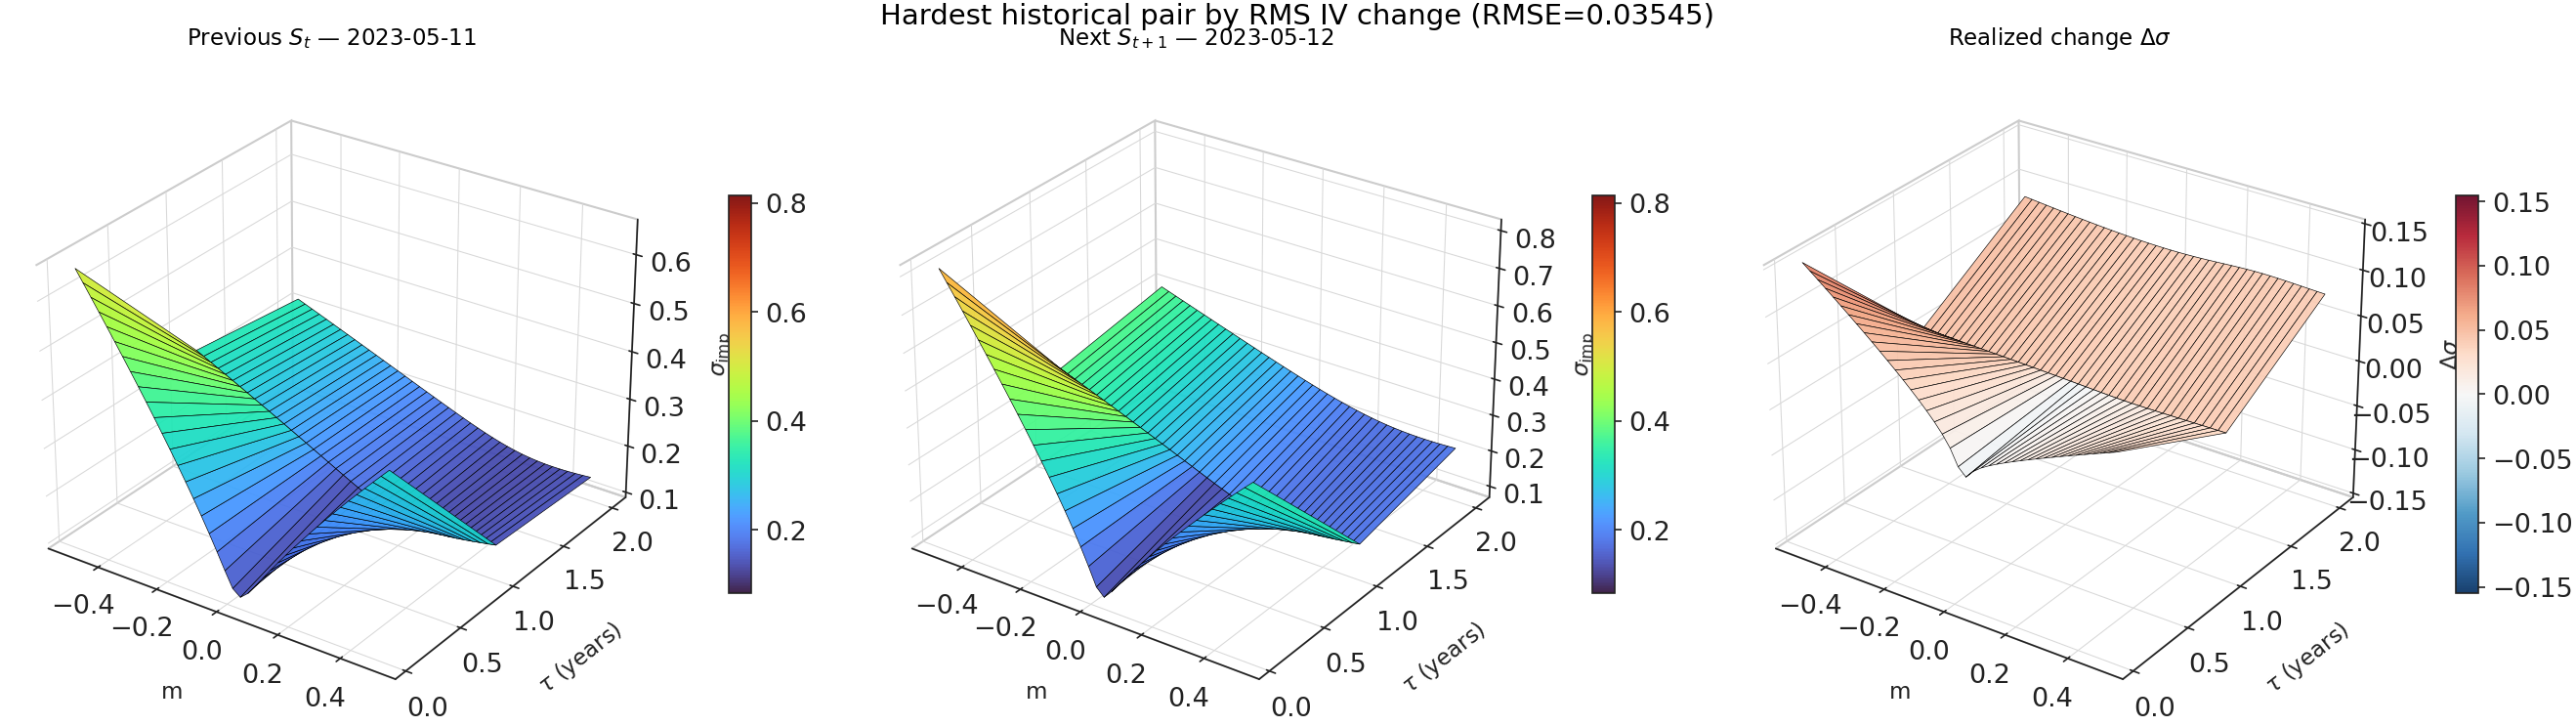

In [4]:
HARD_HIST_AVAILABLE = False
HARD_HIST_J = None
HARD_S_CURR = None
HARD_S_NEXT = None
HARD_HIST_DATE_CURR = None
HARD_HIST_DATE_NEXT = None
HARD_HIST_JUMP_RMSE = None
HARD_HIST_MAX_ABS_DELTA = None

hist_mask = val_sources == 0
if not hist_mask.any():
    print("No historical validation pairs; nothing to rank.")
else:
    curr_h = val_pair_curr[hist_mask].astype(np.float64)
    next_h = val_pair_next[hist_mask].astype(np.float64)
    delta_h = next_h - curr_h
    rmse = np.sqrt(np.nanmean(delta_h**2, axis=(1, 2)))
    j = int(np.argmax(rmse))
    s_curr = curr_h[j]
    s_next = next_h[j]
    d0 = val_hist_curr_dates[j]
    d1 = val_hist_next_dates[j]

    HARD_HIST_AVAILABLE = True
    HARD_HIST_J = j
    HARD_S_CURR = np.asarray(s_curr, dtype=np.float64)
    HARD_S_NEXT = np.asarray(s_next, dtype=np.float64)
    HARD_HIST_DATE_CURR = d0
    HARD_HIST_DATE_NEXT = d1
    HARD_HIST_JUMP_RMSE = float(rmse[j])
    HARD_HIST_MAX_ABS_DELTA = float(np.nanmax(np.abs(delta_h[j])))

    print(
        f"Largest historical IV jump: within-hist index j={j}  "
        f"RMSE(S_{{t+1}} - S_t)={HARD_HIST_JUMP_RMSE:.6f}  "
        f"max|\u0394\u03c3|={HARD_HIST_MAX_ABS_DELTA:.6f}"
    )
    print(f"  previous quote date: {d0.date()}  \u2192  next quote date: {d1.date()}")

    m_axis = np.asarray(GRID.log_moneyness, dtype=np.float64)
    tau_axis = np.asarray(GRID.tau, dtype=np.float64)
    MM_5, TT_5 = np.meshgrid(m_axis, tau_axis[tenor_idx], indexing="ij")
    delta = s_next - s_curr
    shared_iv = np.concatenate([s_curr[:, tenor_idx].ravel(), s_next[:, tenor_idx].ravel()])
    shared_vmin = float(np.nanmin(shared_iv))
    shared_vmax = float(np.nanmax(shared_iv))
    if (not np.isfinite(shared_vmin)) or (not np.isfinite(shared_vmax)) or shared_vmin == shared_vmax:
        shared_vmin, shared_vmax = 0.0, 1.0

    panels = [
        (
            s_curr,
            f"Previous $S_t$ \u2014 {d0.date()}",
            SURF_CMAP,
            r"$\sigma_{\mathrm{imp}}$",
            False,
            shared_vmin,
            shared_vmax,
        ),
        (
            s_next,
            f"Next $S_{{t+1}}$ \u2014 {d1.date()}",
            SURF_CMAP,
            r"$\sigma_{\mathrm{imp}}$",
            False,
            shared_vmin,
            shared_vmax,
        ),
        (delta, r"Realized change $\Delta\sigma$", DIFF_CMAP, r"$\Delta\sigma$", True, None, None),
    ]

    fig = plt.figure(figsize=(18.0, 5.2))
    fig.patch.set_facecolor(plt.rcParams["figure.facecolor"])
    fig.suptitle(
        f"Hardest historical pair by RMS IV change (RMSE={rmse[j]:.5f})",
        fontsize=14,
    )
    for col, (iv, title, cmap, zlabel, is_diff, vmin_i, vmax_i) in enumerate(panels):
        ax = fig.add_subplot(1, 3, col + 1, projection="3d")
        iv_5 = iv[:, tenor_idx]
        if is_diff:
            panel_abs = float(np.nanmax(np.abs(iv_5)))
            if not np.isfinite(panel_abs) or panel_abs == 0.0:
                panel_abs = 1e-6
            vmin_, vmax_ = -panel_abs, panel_abs
            ax.set_zlim(vmin_, vmax_)
        else:
            vmin_, vmax_ = vmin_i, vmax_i
        surf = ax.plot_surface(
            MM_5,
            TT_5,
            iv_5,
            cmap=cmap,
            vmin=vmin_,
            vmax=vmax_,
            linewidth=0.3,
            edgecolor="k",
            alpha=0.92,
            antialiased=True,
            rstride=1,
            cstride=1,
        )
        ax.set_title(title, fontsize=11, pad=10)
        ax.set_xlabel(r"m", labelpad=8)
        ax.set_ylabel(r"$\tau$ (years)", labelpad=10)
        ax.set_zlabel(zlabel, labelpad=6)
        ax.view_init(elev=28, azim=-55)
        ax.tick_params(pad=2)
        style_3d_axes(ax)
        fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.08, aspect=18)
    fig.tight_layout()
    plt.show()

## Conditional forecast

In [5]:
def _surface_label(src_id, pair_idx):
    if src_id == 0:
        if pair_idx < len(val_hist_curr_dates):
            return (
                f"date={val_hist_curr_dates[pair_idx].date()}",
                f"date={val_hist_next_dates[pair_idx].date()}",
            )
        return f"idx={pair_idx}", f"idx={pair_idx}"
    if src_id == 1:
        path = int(val_heston_paths[pair_idx])
        step = int(val_heston_steps[pair_idx])
        return f"path={path}, step={step}", f"path={path}, step={step + 1}"
    path = int(val_sabr_paths[pair_idx])
    step = int(val_sabr_steps[pair_idx])
    return f"path={path}, step={step}", f"path={path}, step={step + 1}"


def _maybe_guard(iv):
    if not APPLY_SURFACE_REPAIR:
        return np.asarray(iv, dtype=np.float64)
    return repair_iv_surface(
        np.asarray(iv, dtype=np.float64),
        moneyness,
        GRID.tau,
        spot=SPOT_REF,
        rate=RATE_REF,
        settings=FORECAST_REPAIR_SETTINGS,
    )


def _forecast_vs_gt_metrics(forecast, ground_truth):
    diff = np.asarray(forecast, dtype=np.float64) - np.asarray(ground_truth, dtype=np.float64)
    gt_abs = np.abs(np.asarray(ground_truth, dtype=np.float64))
    mape_mask = np.isfinite(diff) & np.isfinite(gt_abs) & (gt_abs > float(IV_FLOOR_SAMPLE))
    return {
        "rmse": float(np.sqrt(np.nanmean(diff * diff))),
        "mae": float(np.nanmean(np.abs(diff))),
        "mape_pct": (
            float(100.0 * np.mean(np.abs(diff[mape_mask]) / gt_abs[mape_mask])) if np.any(mape_mask) else float("nan")
        ),
        "mean_error": float(np.nanmean(diff)),
        "max_abs_error": float(np.nanmax(np.abs(diff))),
    }


def _repair_delta_metrics(raw, repaired):
    delta = np.asarray(repaired, dtype=np.float64) - np.asarray(raw, dtype=np.float64)
    return {
        "repair_rmse": float(np.sqrt(np.nanmean(delta * delta))),
        "repair_mae": float(np.nanmean(np.abs(delta))),
        "repair_max_abs": float(np.nanmax(np.abs(delta))),
    }


@torch.no_grad()
def _conditional_forecast(s_curr, base_seed):
    cond_iv = torch.as_tensor(s_curr, dtype=torch.float32, device=DEVICE)[None, None]
    cond_z = model.normalize(cond_iv)
    seed = int(base_seed)

    if SAMPLER_USE_GENERATOR:
        sample_generator = torch.Generator().manual_seed(seed)
    else:
        sample_generator = None
        torch.manual_seed(seed)

    forecast_iv = (
        sampler.ddim_sample(
            batch_size=1,
            num_steps=DDIM_STEPS,
            eta=0.0,
            cond=cond_z,
            generator=sample_generator,
            clip_z=SAMPLER_CLIP_Z,
        )
        .detach()
        .cpu()
        .numpy()[0, 0]
        .astype(np.float64)
    )
    forecast_raw = np.asarray(forecast_iv, dtype=np.float64)
    guarded = _maybe_guard(forecast_raw)
    report = check_iv_surface_arbitrage(
        guarded,
        moneyness,
        GRID.tau,
        spot=SPOT_REF,
        rate=RATE_REF,
        tol=GENERATED_ARB_TOL,
    )
    raw_report = check_iv_surface_arbitrage(
        forecast_raw,
        moneyness,
        GRID.tau,
        spot=SPOT_REF,
        rate=RATE_REF,
        tol=GENERATED_ARB_TOL,
    )
    meta = {
        "seed": seed,
        "forecast_arb_free": bool(report.arbitrage_free),
        "forecast_raw_arb_free": bool(raw_report.arbitrage_free),
        "forecast_arb_tol": GENERATED_ARB_TOL,
        "worst_butterfly": float(report.worst_butterfly),
        "worst_calendar": float(report.worst_calendar),
        "worst_bound": float(report.worst_bound),
        "raw_worst_butterfly": float(raw_report.worst_butterfly),
        "raw_worst_calendar": float(raw_report.worst_calendar),
        "raw_worst_bound": float(raw_report.worst_bound),
    }
    return guarded, forecast_raw, meta


instances = []
display_instance_indices = {}

for path_type in PATH_TYPES:
    src_id = PATH_TYPE_TO_SRC_ID[path_type]
    n_pairs = pair_curr_by_src[src_id].shape[0]
    if n_pairs == 0:
        raise RuntimeError(f"No validation pairs for source {src_id}")
    _display_rng = np.random.default_rng(VALIDATION_SEED + 5000 + src_id)
    display_pick = int(_display_rng.choice(n_pairs))

    if path_type == "historical":
        pair_indices = range(n_pairs)
        print(f"Forecasting {path_type} — full set ({n_pairs} pairs)...")
    else:
        pair_indices = [display_pick]
        print(f"Forecasting {path_type} — sample 1/{n_pairs} (pair {display_pick})...")

    for j in pair_indices:
        s_curr = pair_curr_by_src[src_id][j].astype(np.float64)
        s_next = pair_next_by_src[src_id][j].astype(np.float64)
        input_label, gt_label = _surface_label(src_id, j)
        seed = VALIDATION_SEED + 9000 + src_id * 10000 + j
        forecast, forecast_raw, meta = _conditional_forecast(s_curr, seed)
        idx = len(instances)
        instances.append(
            {
                "path_type": path_type,
                "pair_idx": j,
                "input_label": input_label,
                "gt_label": gt_label,
                "input": s_curr,
                "ground_truth": s_next,
                "forecast": forecast,
                "forecast_raw": forecast_raw,
                "meta": meta,
            }
        )
        if j == display_pick:
            display_instance_indices[path_type] = idx
        if path_type == "historical" and ((j + 1) % 25 == 0 or j == n_pairs - 1):
            print(f"  historical: {j + 1}/{n_pairs}")

display_instances = [instances[display_instance_indices[pt]] for pt in PATH_TYPES]
n_hist = sum(1 for i in instances if i["path_type"] == "historical")
print(f"\nTotal forecasts: {len(instances)} (historical={n_hist}) | Display instances: {len(display_instances)}")

forecast_repair_metrics_rows = []
for i, inst in enumerate(instances, start=1):
    gt = inst["ground_truth"]
    raw_m = _forecast_vs_gt_metrics(inst["forecast_raw"], gt)
    rep_m = _forecast_vs_gt_metrics(inst["forecast"], gt)
    delta_m = _repair_delta_metrics(inst["forecast_raw"], inst["forecast"])
    forecast_repair_metrics_rows.append(
        {
            "instance": i,
            "path_type": inst["path_type"],
            "pair_idx": int(inst["pair_idx"]),
            "seed": int(inst["meta"]["seed"]),
            "raw_arb_free": bool(inst["meta"]["forecast_raw_arb_free"]),
            "repaired_arb_free": bool(inst["meta"]["forecast_arb_free"]),
            "raw_rmse_vs_gt": raw_m["rmse"],
            "repaired_rmse_vs_gt": rep_m["rmse"],
            "rmse_delta_repaired_minus_raw": rep_m["rmse"] - raw_m["rmse"],
            "raw_mae_vs_gt": raw_m["mae"],
            "repaired_mae_vs_gt": rep_m["mae"],
            "raw_mape_pct_vs_gt": raw_m["mape_pct"],
            "repaired_mape_pct_vs_gt": rep_m["mape_pct"],
            "repair_rmse": delta_m["repair_rmse"],
            "repair_mae": delta_m["repair_mae"],
            "repair_max_abs": delta_m["repair_max_abs"],
            "raw_worst_butterfly": float(inst["meta"]["raw_worst_butterfly"]),
            "raw_worst_calendar": float(inst["meta"]["raw_worst_calendar"]),
            "repaired_worst_butterfly": float(inst["meta"]["worst_butterfly"]),
            "repaired_worst_calendar": float(inst["meta"]["worst_calendar"]),
        }
    )

forecast_repair_metrics_df = pd.DataFrame(forecast_repair_metrics_rows)
display(forecast_repair_metrics_df)

surface_inputs_df = pd.DataFrame(
    [
        {
            "instance": i + 1,
            "path_type": inst["path_type"],
            "pair_idx": int(inst["pair_idx"]),
            "input_label": inst["input_label"],
            "gt_label": inst["gt_label"],
            "seed": int(inst["meta"]["seed"]),
            "forecast_raw_arb_free": bool(inst["meta"]["forecast_raw_arb_free"]),
            "forecast_arb_free": bool(inst["meta"]["forecast_arb_free"]),
            "worst_butterfly": float(inst["meta"]["worst_butterfly"]),
            "worst_calendar": float(inst["meta"]["worst_calendar"]),
            "worst_bound": float(inst["meta"]["worst_bound"]),
            "tenor_years_shown": np.round(GRID.tau[tenor_idx], 4).tolist(),
        }
        for i, inst in enumerate(instances)
    ]
)

Forecasting historical — full set (249 pairs)...
  historical: 25/249
  historical: 50/249
  historical: 75/249
  historical: 100/249
  historical: 125/249
  historical: 150/249
  historical: 175/249
  historical: 200/249
  historical: 225/249
  historical: 249/249
Forecasting sabr — sample 1/238 (pair 29)...
Forecasting heston — sample 1/99 (pair 57)...

Total forecasts: 251 (historical=249) | Display instances: 3


,instance,path_type,pair_idx,seed,raw_arb_free,repaired_arb_free,raw_rmse_vs_gt,repaired_rmse_vs_gt,rmse_delta_repaired_minus_raw,raw_mae_vs_gt,repaired_mae_vs_gt,raw_mape_pct_vs_gt,repaired_mape_pct_vs_gt,repair_rmse,repair_mae,repair_max_abs,raw_worst_butterfly,raw_worst_calendar,repaired_worst_butterfly,repaired_worst_calendar
0,1,historical,0,9042,False,True,0.021085,0.021805,0.000720,0.019700,0.020781,8.476178,9.189458,0.005915,0.003279,0.046657,-0.232362,-0.011520,-3.780959e-15,-4.078545e-05
1,2,historical,1,9043,False,True,0.009691,0.010146,0.000456,0.008417,0.009190,3.629182,4.137165,0.005525,0.002955,0.045876,-0.192627,-0.012624,-3.780959e-15,-9.737218e-06
2,3,historical,2,9044,False,True,0.018777,0.019796,0.001019,0.017183,0.018300,7.710863,8.359136,0.005216,0.003064,0.042000,-0.193056,-0.009482,-3.780959e-15,-4.991094e-05
3,4,historical,3,9045,False,True,0.010224,0.010970,0.000746,0.009121,0.010065,4.090825,4.659182,0.005335,0.003097,0.038929,-0.212580,-0.008987,-7.561918e-15,-2.171800e-05
4,5,historical,4,9046,False,True,0.019425,0.019543,0.000117,0.014334,0.015237,5.962447,6.596194,0.005150,0.003090,0.043285,-0.181615,-0.007856,-3.780959e-15,-4.724593e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,247,historical,246,9288,False,True,0.014405,0.014552,0.000148,0.012220,0.013229,6.124164,6.965572,0.005833,0.003390,0.043486,-0.213049,-0.008209,-7.015520e-15,-9.152064e-05
247,248,historical,247,9289,False,True,0.004363,0.007367,0.003004,0.003088,0.004399,1.576995,2.422033,0.006492,0.003734,0.057334,-0.249776,-0.014162,-3.780959e-15,-7.621679e-05
248,249,historical,248,9290,False,True,0.008444,0.009540,0.001095,0.004819,0.005690,2.116688,2.718134,0.005722,0.003262,0.054124,-0.147606,-0.010058,-6.508603e-15,-5.488529e-05
249,250,sabr,29,29071,False,True,0.001543,0.001475,-0.000068,0.001409,0.001405,3.134795,3.117527,0.000270,0.000214,0.001200,-0.000004,-0.000302,-1.607701e-11,-8.673617e-19


## ATM skew & curvature vs tenor (historical vs forecast)

/var/folders/2s/gqvy1xws0kjgyzj7b4rk7wsw0000gn/T/ipykernel_2227/3057774212.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  mean_fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))


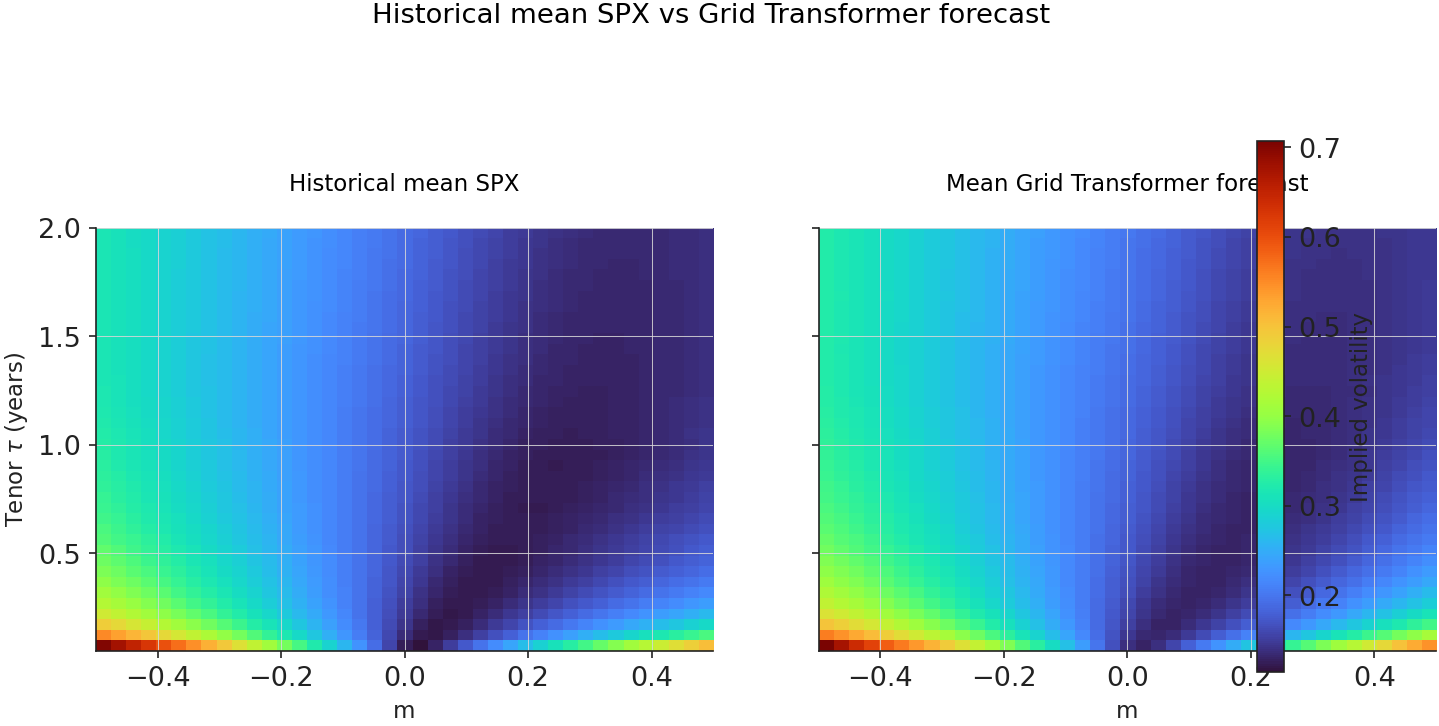

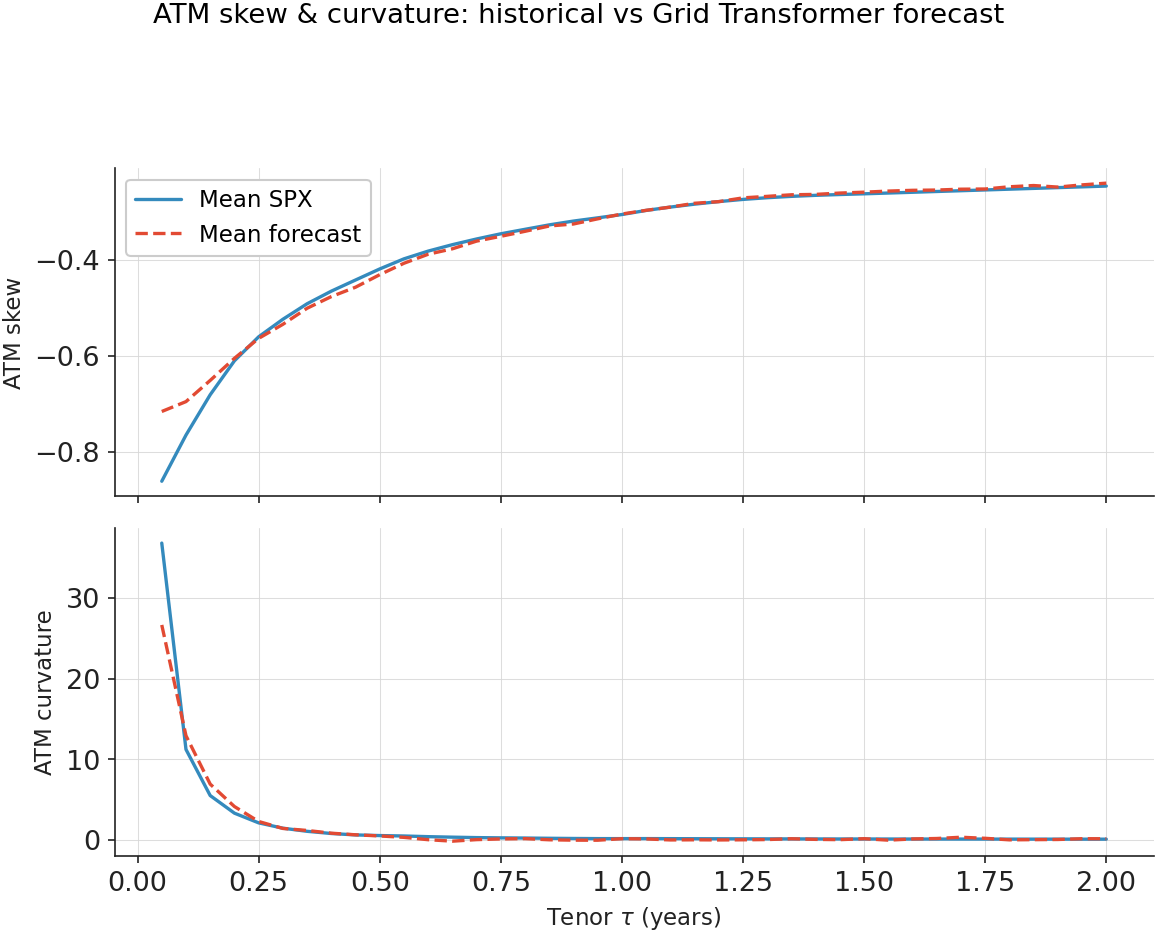

In [6]:
from implied_volatility_diffusion.core.atm_geometry import atm_skew_and_curvature

tau_axis = GRID.tau.astype(np.float64)
hist_insts = [inst for inst in instances if inst["path_type"] == "historical"]
if not hist_insts:
    raise RuntimeError("no historical instances available")

mean_gt = np.nanmean(
    np.stack([np.asarray(inst["ground_truth"], dtype=np.float64) for inst in hist_insts], axis=0),
    axis=0,
)
mean_fc = np.nanmean(
    np.stack([np.asarray(inst["forecast"], dtype=np.float64) for inst in hist_insts], axis=0),
    axis=0,
)
_, sk_gt, cu_gt = atm_skew_and_curvature(mean_gt, GRID)
_, sk_fc, cu_fc = atm_skew_and_curvature(mean_fc, GRID)

m_axis = GRID.log_moneyness.astype(np.float64)
mean_extent = (float(m_axis[0]), float(m_axis[-1]), float(tau_axis[0]), float(tau_axis[-1]))
mean_vmin = float(np.nanmin([mean_gt.min(), mean_fc.min()]))
mean_vmax = float(np.nanmax([mean_gt.max(), mean_fc.max()]))

mean_fig, mean_axes = plt.subplots(1, 2, figsize=(10, 4.6), sharey=True)
mean_fig.patch.set_facecolor(plt.rcParams["figure.facecolor"])
mean_image = None
for ax, surface, title in zip(
    mean_axes,
    (mean_gt, mean_fc),
    ("Historical mean SPX", "Mean Grid Transformer forecast"),
    strict=False,
):
    mean_image = ax.imshow(
        surface.T,
        origin="lower",
        aspect="auto",
        extent=mean_extent,
        cmap=SURF_CMAP,
        vmin=mean_vmin,
        vmax=mean_vmax,
    )
    ax.set_title(title, y=1.04, pad=10)
    ax.set_xlabel(r"m")
mean_axes[0].set_ylabel(r"Tenor $\tau$ (years)")
mean_fig.colorbar(mean_image, ax=mean_axes, fraction=0.046, pad=0.04, label="Implied volatility")
mean_fig.suptitle("Historical mean SPX vs Grid Transformer forecast", y=1.08)
mean_fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
mean_fig.savefig("trans_historical_mean_spx_vs_forecast.pdf", format="pdf", bbox_inches="tight")
plt.show()

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
fig.patch.set_facecolor(plt.rcParams["figure.facecolor"])
ax0.plot(tau_axis, sk_gt, label="Mean SPX", color=TENOR_COLORS[0])
ax0.plot(tau_axis, sk_fc, "--", label="Mean forecast", color=TENOR_COLORS[1])
ax0.set_ylabel(r"ATM skew")
ax0.legend(loc="best")

ax1.plot(tau_axis, cu_gt, color=TENOR_COLORS[0], label="Mean SPX")
ax1.plot(tau_axis, cu_fc, "--", color=TENOR_COLORS[1], label="Mean forecast")
ax1.set_xlabel(r"Tenor $\tau$ (years)")
ax1.set_ylabel(r"ATM curvature")

fig.suptitle("ATM skew & curvature: historical vs Grid Transformer forecast", y=1.06)
style_2d_axes(ax0)
style_2d_axes(ax1)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
fig.savefig("trans_atm_skew_and_curvature.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Model forecast on the largest historical IV jump

Largest historical IV jump — forecast metrics vs GT:
  Unrepaired: RMSE=0.026640  MAE=0.018836  arb_free=False
  Repaired:   RMSE=0.027544  MAE=0.020390  arb_free=True  seed=7742
  Repair Δ:   RMSE=0.008067  MAE=0.004129  max|Δ|=0.064405
  Realized jump (GT − prev) RMS=0.035449 — forecast error measures how well the model predicts that move from $S_t$.


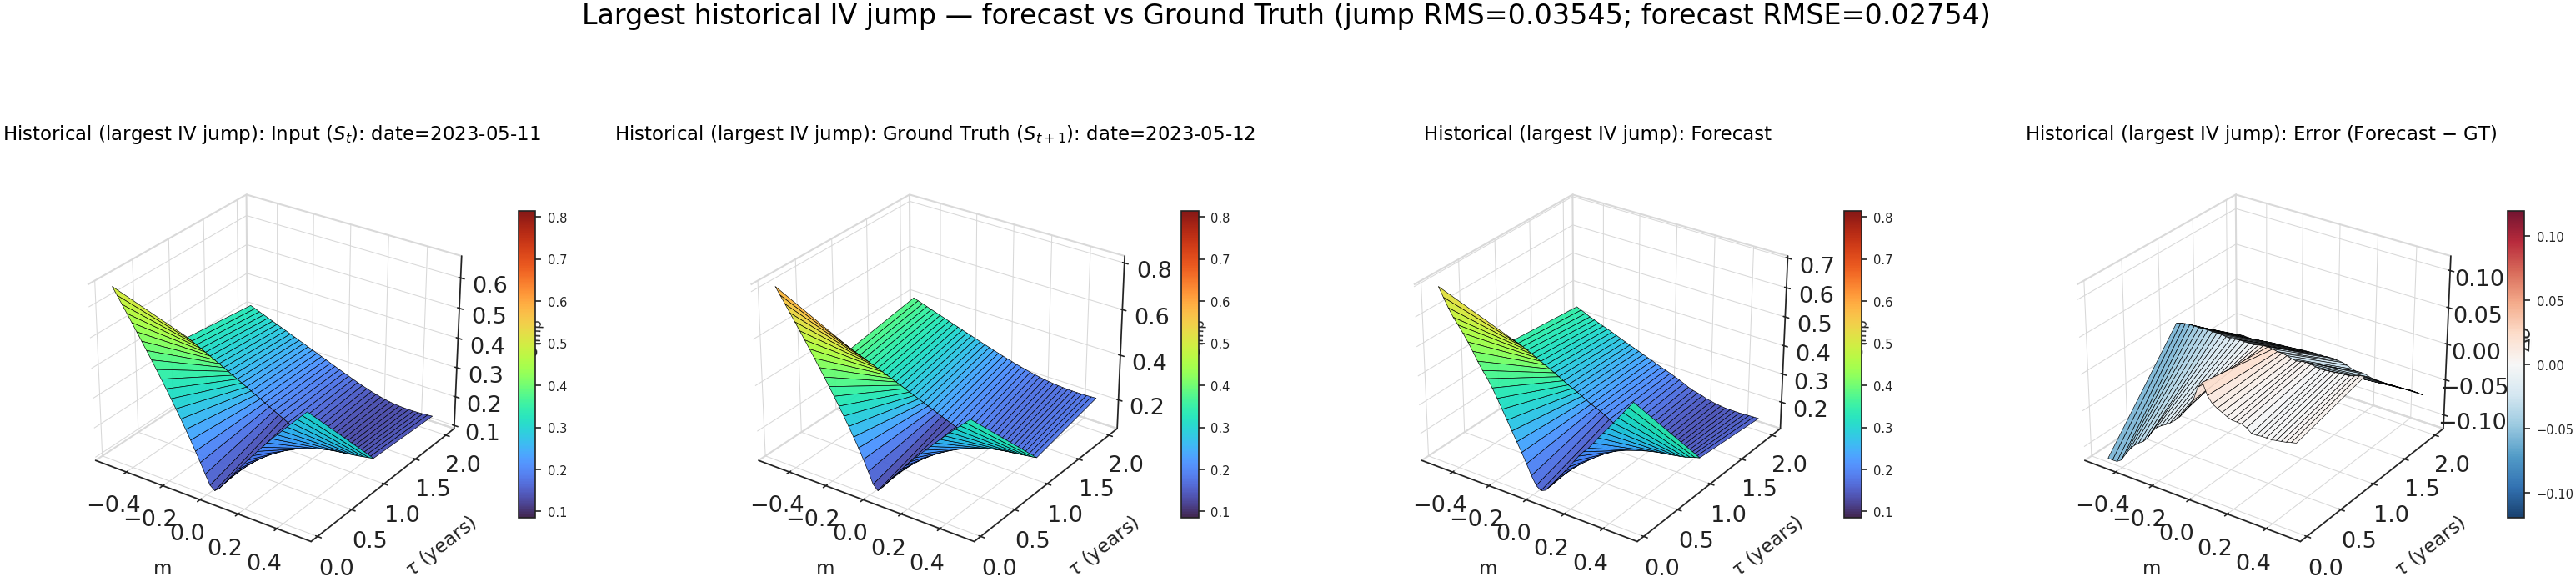

In [7]:
if not HARD_HIST_AVAILABLE:
    print("Skipping model comparison: no historical validation pairs.")
else:
    HARD_JUMP_FORECAST_SEED = int(VALIDATION_SEED + 7700)
    hard_forecast, hard_forecast_raw, hard_meta = _conditional_forecast(HARD_S_CURR, HARD_JUMP_FORECAST_SEED)
    hard_raw_m = _forecast_vs_gt_metrics(hard_forecast_raw, HARD_S_NEXT)
    hard_rep_m = _forecast_vs_gt_metrics(hard_forecast, HARD_S_NEXT)
    hard_delta_m = _repair_delta_metrics(hard_forecast_raw, hard_forecast)
    hard_rmse = hard_rep_m["rmse"]
    hard_mae = hard_rep_m["mae"]
    print("Largest historical IV jump \u2014 forecast metrics vs GT:")
    print(
        f"  Unrepaired: RMSE={hard_raw_m['rmse']:.6f}  MAE={hard_raw_m['mae']:.6f}  "
        f"arb_free={hard_meta['forecast_raw_arb_free']}"
    )
    print(
        f"  Repaired:   RMSE={hard_rep_m['rmse']:.6f}  MAE={hard_rep_m['mae']:.6f}  "
        f"arb_free={hard_meta['forecast_arb_free']}  seed={hard_meta['seed']}"
    )
    print(
        f"  Repair \u0394:   RMSE={hard_delta_m['repair_rmse']:.6f}  MAE={hard_delta_m['repair_mae']:.6f}  "
        f"max|\u0394|={hard_delta_m['repair_max_abs']:.6f}"
    )
    print(
        f"  Realized jump (GT \u2212 prev) RMS={HARD_HIST_JUMP_RMSE:.6f} \u2014 "
        "forecast error measures how well the model predicts that move from $S_t$."
    )

    m_axis = np.asarray(GRID.log_moneyness, dtype=np.float64)
    tau_axis = np.asarray(GRID.tau, dtype=np.float64)
    MM_5, TT_5 = np.meshgrid(m_axis, tau_axis[tenor_idx], indexing="ij")

    inst = {
        "input": HARD_S_CURR,
        "ground_truth": HARD_S_NEXT,
        "forecast": hard_forecast,
        "input_label": f"date={HARD_HIST_DATE_CURR.date()}",
        "gt_label": f"date={HARD_HIST_DATE_NEXT.date()}",
    }

    with rc_context():
        from matplotlib.ticker import FormatStrFormatter

        fig3d = plt.figure(figsize=(26.0, 5.8))
        fig3d.patch.set_facecolor(plt.rcParams["figure.facecolor"])
        fig3d.subplots_adjust(wspace=0.25, hspace=0.35)

        path_label = "Historical (largest IV jump)"
        panels = [
            (inst["input"], f"Input ($S_t$): {inst['input_label']}", SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
            (
                inst["ground_truth"],
                f"Ground Truth ($S_{{t+1}}$): {inst['gt_label']}",
                SURF_CMAP,
                r"$\sigma_{\mathrm{imp}}$",
                False,
            ),
            (inst["forecast"], "Forecast", SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
            (inst["forecast"] - inst["ground_truth"], "Error (Forecast $-$ GT)", DIFF_CMAP, r"$\Delta\sigma$", True),
        ]

        all_iv_vals = np.concatenate(
            [
                inst["input"][:, tenor_idx].ravel(),
                inst["ground_truth"][:, tenor_idx].ravel(),
                inst["forecast"][:, tenor_idx].ravel(),
            ]
        )
        shared_vmin = float(np.nanmin(all_iv_vals))
        shared_vmax = float(np.nanmax(all_iv_vals))
        if (not np.isfinite(shared_vmin)) or (not np.isfinite(shared_vmax)) or shared_vmin == shared_vmax:
            shared_vmin, shared_vmax = 0.0, 1.0

        for col, (iv, title, cmap, zlabel, is_diff) in enumerate(panels):
            ax = fig3d.add_subplot(1, 4, col + 1, projection="3d")
            iv_5 = iv[:, tenor_idx]
            if is_diff:
                panel_abs = float(np.nanmax(np.abs(iv_5)))
                if not np.isfinite(panel_abs) or panel_abs == 0.0:
                    panel_abs = 1.0
                vmin_, vmax_ = -panel_abs, panel_abs
                ax.set_zlim(vmin_, vmax_)
            else:
                vmin_, vmax_ = shared_vmin, shared_vmax

            plotted = ax.plot_surface(
                MM_5,
                TT_5,
                iv_5,
                cmap=cmap,
                vmin=vmin_,
                vmax=vmax_,
                linewidth=0.3,
                edgecolor="k",
                alpha=0.92,
                antialiased=True,
                rstride=1,
                cstride=1,
            )
            ax.set_title(f"{path_label}: {title}", fontsize=11, pad=12)
            ax.set_xlabel(r"m", labelpad=8)
            ax.set_ylabel(r"$\tau$ (years)", labelpad=10)
            ax.set_zlabel(zlabel, labelpad=6)
            ax.view_init(elev=28, azim=-55)
            ax.tick_params(pad=2)
            style_3d_axes(ax)
            ax.xaxis.pane.set_edgecolor("0.85")
            ax.yaxis.pane.set_edgecolor("0.85")
            ax.zaxis.pane.set_edgecolor("0.85")
            cbar = fig3d.colorbar(plotted, ax=ax, shrink=0.55, pad=0.08, aspect=18)
            cbar.ax.tick_params(labelsize=7)


        repair_panels = [
            (
                hard_forecast_raw,
                f"Unrepaired\nRMSE={hard_raw_m['rmse']:.3f}  arb={hard_meta.get('forecast_raw_arb_free', False)}",
                SURF_CMAP,
                r"$\sigma_{\mathrm{imp}}$",
                False,
            ),
            (
                hard_forecast,
                f"Repaired\nRMSE={hard_rep_m['rmse']:.3f}  arb={hard_meta['forecast_arb_free']}",
                SURF_CMAP,
                r"$\sigma_{\mathrm{imp}}$",
                False,
            ),
            (
                hard_forecast - hard_forecast_raw,
                f"Repair Δ\nRMSE={hard_delta_m['repair_rmse']:.3f}",
                DIFF_CMAP,
                r"$\Delta\sigma$",
                True,
            ),
        ]
        all_fc = np.concatenate([hard_forecast_raw[:, tenor_idx].ravel(), hard_forecast[:, tenor_idx].ravel()])
        fc_vmin = float(np.nanmin(all_fc))
        fc_vmax = float(np.nanmax(all_fc))
        if (not np.isfinite(fc_vmin)) or (not np.isfinite(fc_vmax)) or fc_vmin == fc_vmax:
            fc_vmin, fc_vmax = 0.0, 1.0

        fig3d_repair = plt.figure(figsize=(22.0, 5.8))
        fig3d_repair.patch.set_facecolor(plt.rcParams["figure.facecolor"])
        fig3d_repair.subplots_adjust(wspace=0.28, hspace=0.35)
        for col, (iv, title, cmap, zlabel, is_diff) in enumerate(repair_panels):
            ax = fig3d_repair.add_subplot(1, 3, col + 1, projection="3d")
            iv_5 = iv[:, tenor_idx]
            if is_diff:
                panel_abs = float(np.nanmax(np.abs(iv_5)))
                if not np.isfinite(panel_abs) or panel_abs == 0.0:
                    panel_abs = 1.0
                vmin_, vmax_ = -panel_abs, panel_abs
                ax.set_zlim(vmin_, vmax_)
            else:
                vmin_, vmax_ = fc_vmin, fc_vmax

            plotted = ax.plot_surface(
                MM_5,
                TT_5,
                iv_5,
                cmap=cmap,
                vmin=vmin_,
                vmax=vmax_,
                linewidth=0.3,
                edgecolor="k",
                alpha=0.92,
                antialiased=True,
                rstride=1,
                cstride=1,
            )
            ax.set_title(f"{path_label}: {title}", fontsize=11, pad=12)
            ax.set_xlabel(r"m", labelpad=8)
            ax.set_ylabel(r"$\tau$ (years)", labelpad=10)
            ax.set_zlabel("")
            ax.view_init(elev=28, azim=-55)
            ax.tick_params(pad=2)
            style_3d_axes(ax)
            ax.set_zticklabels([])
            cbar = fig3d_repair.colorbar(plotted, ax=ax, shrink=0.55, pad=0.08, aspect=18)
            cbar.set_label(zlabel)
            cbar.ax.tick_params(labelsize=7)
            cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

        plt.show()

        fig3d.suptitle(
            f"Largest historical IV jump \u2014 forecast vs Ground Truth (jump RMS={HARD_HIST_JUMP_RMSE:.5f}; "
            f"forecast RMSE={hard_rmse:.5f})",
            fontsize=16,
            y=0.995,
        )
        fig3d.savefig(
            "trans_validation_hard_jump_heatmap_ground_truth_vs_forecast.pdf", format="pdf", bbox_inches="tight"
        )
        plt.show()

## No-arbitrage diagnostics

In [8]:
def _report_row(kind, instance, path_type, label, iv):
    strict = check_iv_surface_arbitrage(iv, moneyness, GRID.tau, spot=SPOT_REF, rate=RATE_REF, tol=ARB_DIAG_TOL)
    soft = check_iv_surface_arbitrage(iv, moneyness, GRID.tau, spot=SPOT_REF, rate=RATE_REF, tol=ARB_ACCEPT_TOL)
    return {
        "instance": instance,
        "path_type": path_type,
        "kind": kind,
        "label": label,
        "strict_arb_free": bool(strict.arbitrage_free),
        "soft_arb_free": bool(soft.arbitrage_free),
        "worst_butterfly": float(strict.worst_butterfly),
        "worst_calendar": float(strict.worst_calendar),
        "worst_bound": float(strict.worst_bound),
        "n_butterfly": int(strict.n_butterfly_violations),
        "n_calendar": int(strict.n_calendar_violations),
        "n_bound": int(strict.n_bound_violations),
    }


validation_rows = []
for i, inst in enumerate(display_instances, start=1):
    path_type = str(inst["path_type"])
    validation_rows.append(
        _report_row(f"input ($S_t$): {inst['input_label']}", i, path_type, inst["input_label"], inst["input"])
    )
    validation_rows.append(
        _report_row(
            f"ground truth ($S_{{t+1}}$): {inst['gt_label']}", i, path_type, inst["gt_label"], inst["ground_truth"]
        )
    )
    validation_rows.append(
        _report_row(
            "forecast (unrepaired)",
            i,
            path_type,
            f"forecast raw (seed={inst['meta']['seed']})",
            inst["forecast_raw"],
        )
    )
    validation_rows.append(
        _report_row(
            "forecast (repaired)",
            i,
            path_type,
            f"forecast repaired (seed={inst['meta']['seed']})",
            inst["forecast"],
        )
    )

surface_validation_df = pd.DataFrame(validation_rows)

display(
    forecast_repair_metrics_df[
        [
            "instance",
            "path_type",
            "raw_arb_free",
            "repaired_arb_free",
            "raw_rmse_vs_gt",
            "repaired_rmse_vs_gt",
            "rmse_delta_repaired_minus_raw",
            "raw_mae_vs_gt",
            "repaired_mae_vs_gt",
            "repair_rmse",
            "repair_max_abs",
        ]
    ].rename(
        columns={
            "raw_arb_free": "unrepaired_arb_free",
            "repaired_arb_free": "repaired_arb_free",
            "raw_rmse_vs_gt": "unrepaired_rmse",
            "repaired_rmse_vs_gt": "repaired_rmse",
            "rmse_delta_repaired_minus_raw": "rmse_change",
            "raw_mae_vs_gt": "unrepaired_mae",
            "repaired_mae_vs_gt": "repaired_mae",
            "repair_rmse": "repair_magnitude_rmse",
            "repair_max_abs": "repair_max_abs",
        }
    )
)

forecast_error_rows = []
for i, inst in enumerate(instances, start=1):
    gt = inst["ground_truth"]
    for variant, fc in (("unrepaired", inst["forecast_raw"]), ("repaired", inst["forecast"])):
        m = _forecast_vs_gt_metrics(fc, gt)
        forecast_error_rows.append(
            {
                "instance": i,
                "path_type": inst["path_type"],
                "forecast_variant": variant,
                "rmse": m["rmse"],
                "mae": m["mae"],
                "mape_pct": m["mape_pct"],
                "mean_error": m["mean_error"],
                "max_abs_error": m["max_abs_error"],
            }
        )

forecast_error_df = pd.DataFrame(forecast_error_rows)
display(surface_validation_df)

,instance,path_type,unrepaired_arb_free,repaired_arb_free,unrepaired_rmse,repaired_rmse,rmse_change,unrepaired_mae,repaired_mae,repair_magnitude_rmse,repair_max_abs
0,1,historical,False,True,0.021085,0.021805,0.000720,0.019700,0.020781,0.005915,0.046657
1,2,historical,False,True,0.009691,0.010146,0.000456,0.008417,0.009190,0.005525,0.045876
2,3,historical,False,True,0.018777,0.019796,0.001019,0.017183,0.018300,0.005216,0.042000
3,4,historical,False,True,0.010224,0.010970,0.000746,0.009121,0.010065,0.005335,0.038929
4,5,historical,False,True,0.019425,0.019543,0.000117,0.014334,0.015237,0.005150,0.043285
...,...,...,...,...,...,...,...,...,...,...,...
246,247,historical,False,True,0.014405,0.014552,0.000148,0.012220,0.013229,0.005833,0.043486
247,248,historical,False,True,0.004363,0.007367,0.003004,0.003088,0.004399,0.006492,0.057334
248,249,historical,False,True,0.008444,0.009540,0.001095,0.004819,0.005690,0.005722,0.054124
249,250,sabr,False,True,0.001543,0.001475,-0.000068,0.001409,0.001405,0.000270,0.001200


,instance,path_type,kind,label,strict_arb_free,soft_arb_free,worst_butterfly,worst_calendar,worst_bound,n_butterfly,n_calendar,n_bound
0,1,historical,input ($S_t$): date=2023-04-24,date=2023-04-24,False,False,1.971926e-09,-1.774260e-03,1.095854e-07,0,65,0
1,1,historical,ground truth ($S_{t+1}$): date=2023-04-25,date=2023-04-25,False,False,2.146627e-09,-2.525801e-03,1.052914e-07,0,71,0
2,1,historical,forecast (unrepaired),forecast raw (seed=9118),False,False,-1.737868e-01,-1.196299e-02,2.175158e-07,476,237,0
3,1,historical,forecast (repaired),forecast repaired (seed=9118),False,True,-7.561918e-15,-4.846469e-05,1.637146e-05,0,14,0
4,2,sabr,"input ($S_t$): path=13, step=29","path=13, step=29",True,True,-3.780959e-15,6.412526e-05,-2.131628e-14,0,0,0
5,2,sabr,"ground truth ($S_{t+1}$): path=13, step=30","path=13, step=30",True,True,-3.780959e-15,6.591948e-05,-2.131628e-14,0,0,0
6,2,sabr,forecast (unrepaired),forecast raw (seed=29071),False,False,-4.239325e-06,-3.023454e-04,-2.131628e-14,1,163,0
7,2,sabr,forecast (repaired),forecast repaired (seed=29071),True,True,-1.607701e-11,-8.673617e-19,-2.131628e-14,0,0,0
8,3,heston,"input ($S_t$): path=12, step=57","path=12, step=57",True,True,3.177062e-07,4.334185e-03,4.849070e-07,0,0,0
9,3,heston,"ground truth ($S_{t+1}$): path=12, step=58","path=12, step=58",True,True,6.068432e-07,4.349332e-03,1.124582e-06,0,0,0


## IV surface moments (historic input, ground truth, and forecasts)

Pooled and per-instance summary statistics over all finite grid cells: mean, standard deviation, minimum, median, maximum, skewness, and excess kurtosis.


In [9]:
from scipy import stats as scipy_stats

_IV_STATS_DECIMALS = 3
_MOMENT_COLS = ("mean", "std", "min", "median", "max", "skewness", "excess_kurtosis")
_SURFACE_SPECS = (
    ("historic_input", "input"),
    ("ground_truth", "ground_truth"),
    ("forecast_repaired", "forecast"),
    ("forecast_raw", "forecast_raw"),
)


def _round_iv_stat(x: float) -> float:
    x = float(x)
    return round(x, _IV_STATS_DECIMALS) if np.isfinite(x) else float("nan")


def _finite_iv_stats(iv: np.ndarray) -> dict:
    v = np.asarray(iv, dtype=np.float64).ravel()
    v = v[np.isfinite(v)]
    if v.size == 0:
        nan = float("nan")
        return {
            "n": 0,
            "mean": nan,
            "std": nan,
            "min": nan,
            "median": nan,
            "max": nan,
            "skewness": nan,
            "excess_kurtosis": nan,
        }
    return {
        "n": int(v.size),
        "mean": _round_iv_stat(np.mean(v)),
        "std": _round_iv_stat(np.std(v, ddof=1)) if v.size > 1 else 0.0,
        "min": _round_iv_stat(np.min(v)),
        "median": _round_iv_stat(np.median(v)),
        "max": _round_iv_stat(np.max(v)),
        "skewness": _round_iv_stat(scipy_stats.skew(v, bias=False)) if v.size > 2 else float("nan"),
        "excess_kurtosis": (
            _round_iv_stat(scipy_stats.kurtosis(v, fisher=True, bias=False)) if v.size > 3 else float("nan")
        ),
    }


def _surface_moment_row(*, scope: str, instance, path_type: str, surface: str, iv: np.ndarray) -> dict:
    row = {
        "scope": scope,
        "instance": instance,
        "path_type": path_type,
        "surface": surface,
    }
    row.update(_finite_iv_stats(iv))
    return row


def _moments_table_for_instances(scope: str, inst_list: list, *, instance_key) -> pd.DataFrame:
    rows = []
    for inst in inst_list:
        instance = instance_key(inst)
        path_type = str(inst["path_type"])
        for surface_label, iv_key in _SURFACE_SPECS:
            rows.append(
                _surface_moment_row(
                    scope=scope,
                    instance=instance,
                    path_type=path_type,
                    surface=surface_label,
                    iv=inst[iv_key],
                )
            )
    cols = ["scope", "instance", "path_type", "surface", "n", *_MOMENT_COLS]
    return pd.DataFrame(rows, columns=cols) if rows else pd.DataFrame(columns=cols)


iv_hist_instances = [inst for inst in instances if inst["path_type"] == "historical"]

iv_surface_moments_df = _moments_table_for_instances(
    "display_instance",
    display_instances,
    instance_key=lambda inst: int(display_instances.index(inst)) + 1,
)
display(iv_surface_moments_df)

if iv_hist_instances:
    iv_hist_gt_eval = np.concatenate([inst["ground_truth"].ravel() for inst in iv_hist_instances])
    iv_hist_fc_eval = np.concatenate([inst["forecast"].ravel() for inst in iv_hist_instances])
    iv_hist_in_eval = np.concatenate([inst["input"].ravel() for inst in iv_hist_instances])
    iv_hist_fc_raw_eval = np.concatenate([inst["forecast_raw"].ravel() for inst in iv_hist_instances])

    iv_surface_moments_hist_pooled_df = pd.DataFrame(
        [
            _surface_moment_row(
                scope="historical_pooled",
                instance="all",
                path_type="historical",
                surface=surface_label,
                iv=iv,
            )
            for surface_label, iv in (
                ("historic_input", iv_hist_in_eval),
                ("ground_truth", iv_hist_gt_eval),
                ("forecast_repaired", iv_hist_fc_eval),
                ("forecast_raw", iv_hist_fc_raw_eval),
            )
        ]
    )
    display(iv_surface_moments_hist_pooled_df)

    iv_surface_moments_hist_by_instance_df = _moments_table_for_instances(
        "historical_instance",
        iv_hist_instances,
        instance_key=lambda inst: int(instances.index(inst)) + 1,
    )
else:
    display(iv_surface_moments_hist_by_instance_df)

    iv_hist_gt_eval = np.array([], dtype=np.float64)
    iv_hist_fc_eval = np.array([], dtype=np.float64)
    iv_surface_moments_hist_pooled_df = pd.DataFrame()
    iv_surface_moments_hist_by_instance_df = pd.DataFrame()
    print("No historical instances in `instances`; skipping pooled / per-instance moment tables.")


,scope,instance,path_type,surface,n,mean,std,min,median,max,skewness,excess_kurtosis
0,display_instance,1,historical,historic_input,1640,0.217,0.083,0.110,0.196,0.626,0.963,0.803
1,display_instance,1,historical,ground_truth,1640,0.219,0.083,0.118,0.200,0.653,1.073,1.444
2,display_instance,1,historical,forecast_repaired,1640,0.225,0.084,0.123,0.207,0.629,0.931,0.697
3,display_instance,1,historical,forecast_raw,1640,0.223,0.085,0.117,0.203,0.661,0.958,0.821
4,display_instance,2,sabr,historic_input,1640,0.046,0.007,0.037,0.045,0.065,0.751,-0.444
5,display_instance,2,sabr,ground_truth,1640,0.047,0.007,0.038,0.045,0.065,0.760,-0.433
6,display_instance,2,sabr,forecast_repaired,1640,0.045,0.008,0.035,0.044,0.064,0.703,-0.496
7,display_instance,2,sabr,forecast_raw,1640,0.045,0.008,0.035,0.044,0.065,0.702,-0.481
8,display_instance,3,heston,historic_input,1640,0.350,0.032,0.316,0.337,0.461,1.229,0.681
9,display_instance,3,heston,ground_truth,1640,0.358,0.036,0.320,0.344,0.475,1.164,0.438


,scope,instance,path_type,surface,n,mean,std,min,median,max,skewness,excess_kurtosis
0,historical_pooled,all,historical,historic_input,408360,0.211,0.084,0.067,0.191,0.951,1.335,3.192
1,historical_pooled,all,historical,ground_truth,408360,0.211,0.084,0.067,0.191,0.951,1.338,3.199
2,historical_pooled,all,historical,forecast_repaired,408360,0.222,0.085,0.087,0.203,0.910,1.224,2.476
3,historical_pooled,all,historical,forecast_raw,408360,0.220,0.087,0.072,0.201,0.961,1.258,2.736


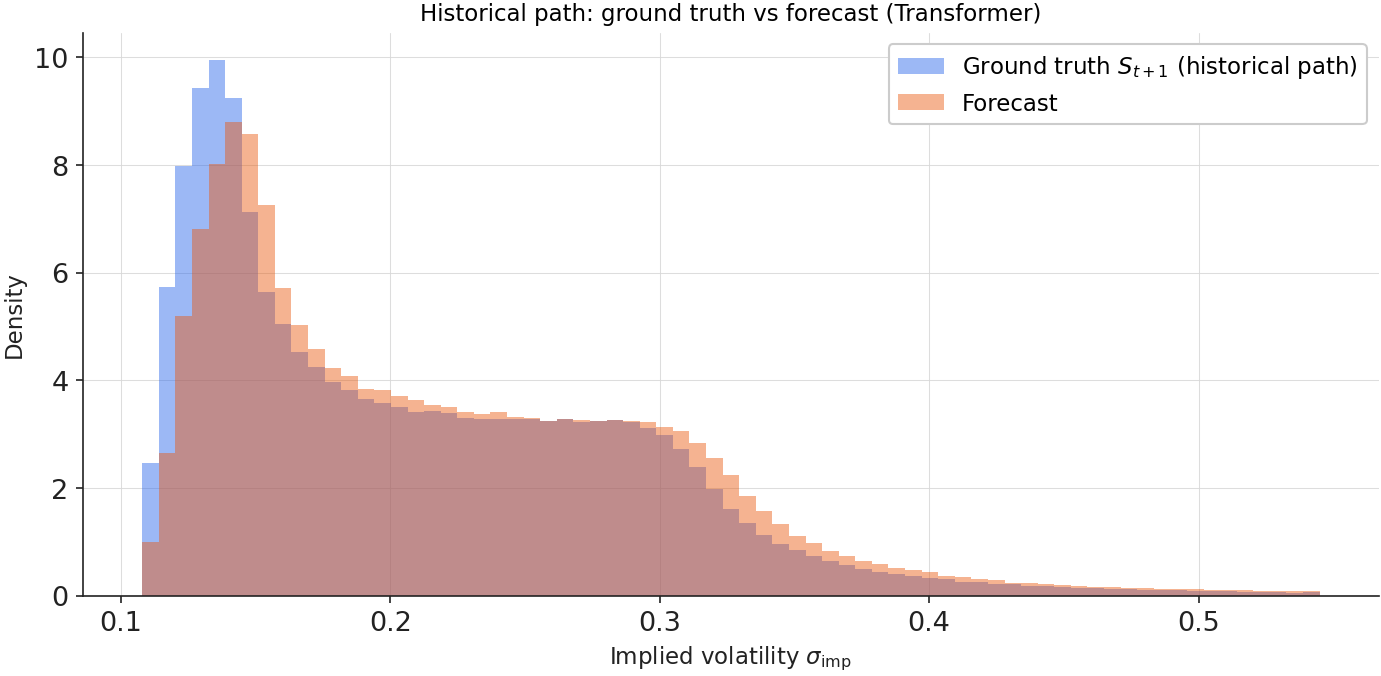

In [10]:
_iv_dist_gt_eval = np.asarray(iv_hist_gt_eval, dtype=np.float64).ravel()
_iv_dist_gt_eval = _iv_dist_gt_eval[np.isfinite(_iv_dist_gt_eval)]
_iv_dist_fc_eval = np.asarray(iv_hist_fc_eval, dtype=np.float64).ravel()
_iv_dist_fc_eval = _iv_dist_fc_eval[np.isfinite(_iv_dist_fc_eval)]

if _iv_dist_gt_eval.size and _iv_dist_fc_eval.size:
    _iv_dist_combined = np.concatenate([_iv_dist_gt_eval, _iv_dist_fc_eval])
    _iv_dist_lo, _iv_dist_hi = np.percentile(_iv_dist_combined, [0.5, 99.5])
    if not np.isfinite(_iv_dist_lo) or not np.isfinite(_iv_dist_hi) or _iv_dist_lo >= _iv_dist_hi:
        _iv_dist_lo, _iv_dist_hi = float(np.min(_iv_dist_combined)), float(np.max(_iv_dist_combined))
    if _iv_dist_lo >= _iv_dist_hi:
        _iv_dist_hi = _iv_dist_lo + 1e-6
    _iv_dist_bins = np.linspace(_iv_dist_lo, _iv_dist_hi, 72)

    _fig_iv_dist, _ax_iv_dist = plt.subplots(figsize=(9.5, 4.8))
    _fig_iv_dist.patch.set_facecolor(plt.rcParams["figure.facecolor"])
    _ax_iv_dist.hist(
        _iv_dist_gt_eval,
        bins=_iv_dist_bins,
        density=True,
        alpha=0.45,
        color="#2563eb",
        label="Ground truth $S_{t+1}$ (historical path)",
        histtype="stepfilled",
        edgecolor="none",
    )
    _ax_iv_dist.hist(
        _iv_dist_fc_eval,
        bins=_iv_dist_bins,
        density=True,
        alpha=0.45,
        color="#ea580c",
        label="Forecast",
        histtype="stepfilled",
        edgecolor="none",
    )
    _ax_iv_dist.set_xlabel(r"Implied volatility $\sigma_{\mathrm{imp}}$")
    _ax_iv_dist.set_ylabel("Density")
    _ax_iv_dist.set_title("Historical path: ground truth vs forecast (Transformer)")
    _ax_iv_dist.legend(loc="upper right", frameon=True)
    style_2d_axes(_ax_iv_dist)
    _fig_iv_dist.tight_layout()
    _fig_iv_dist.savefig("trans_historical_path_gt_vs_forecast_iv_distribution.pdf", format="pdf", bbox_inches="tight")
    plt.show()
else:
    print("Skipping IV histogram: missing historical GT/forecast samples.")

## Model forecast

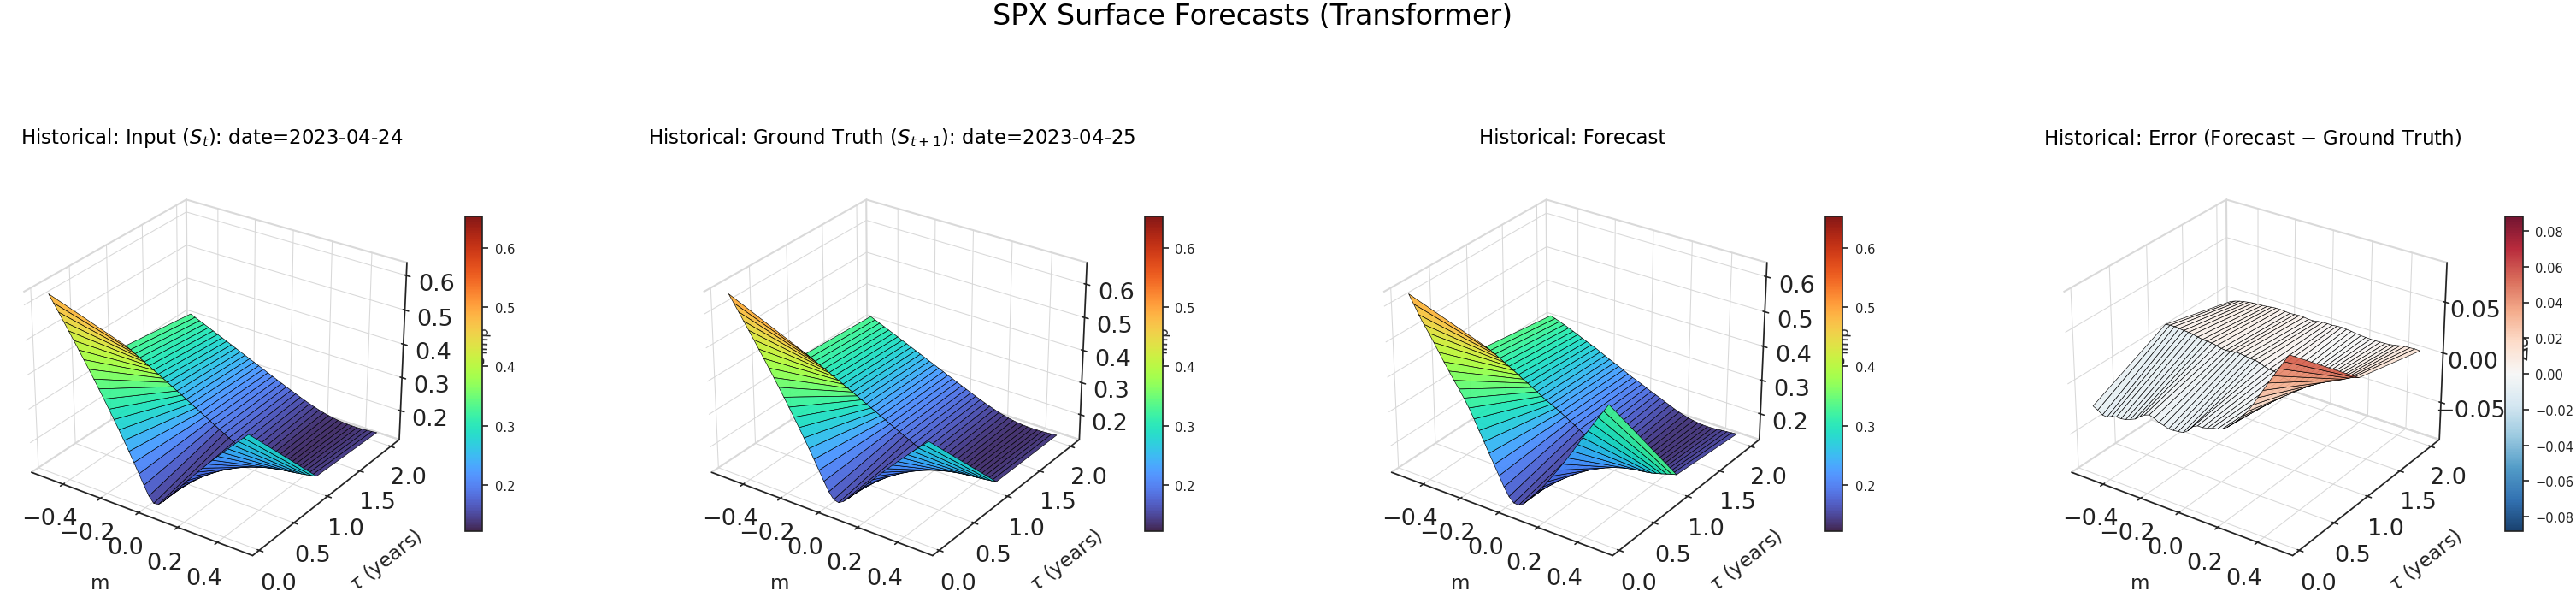

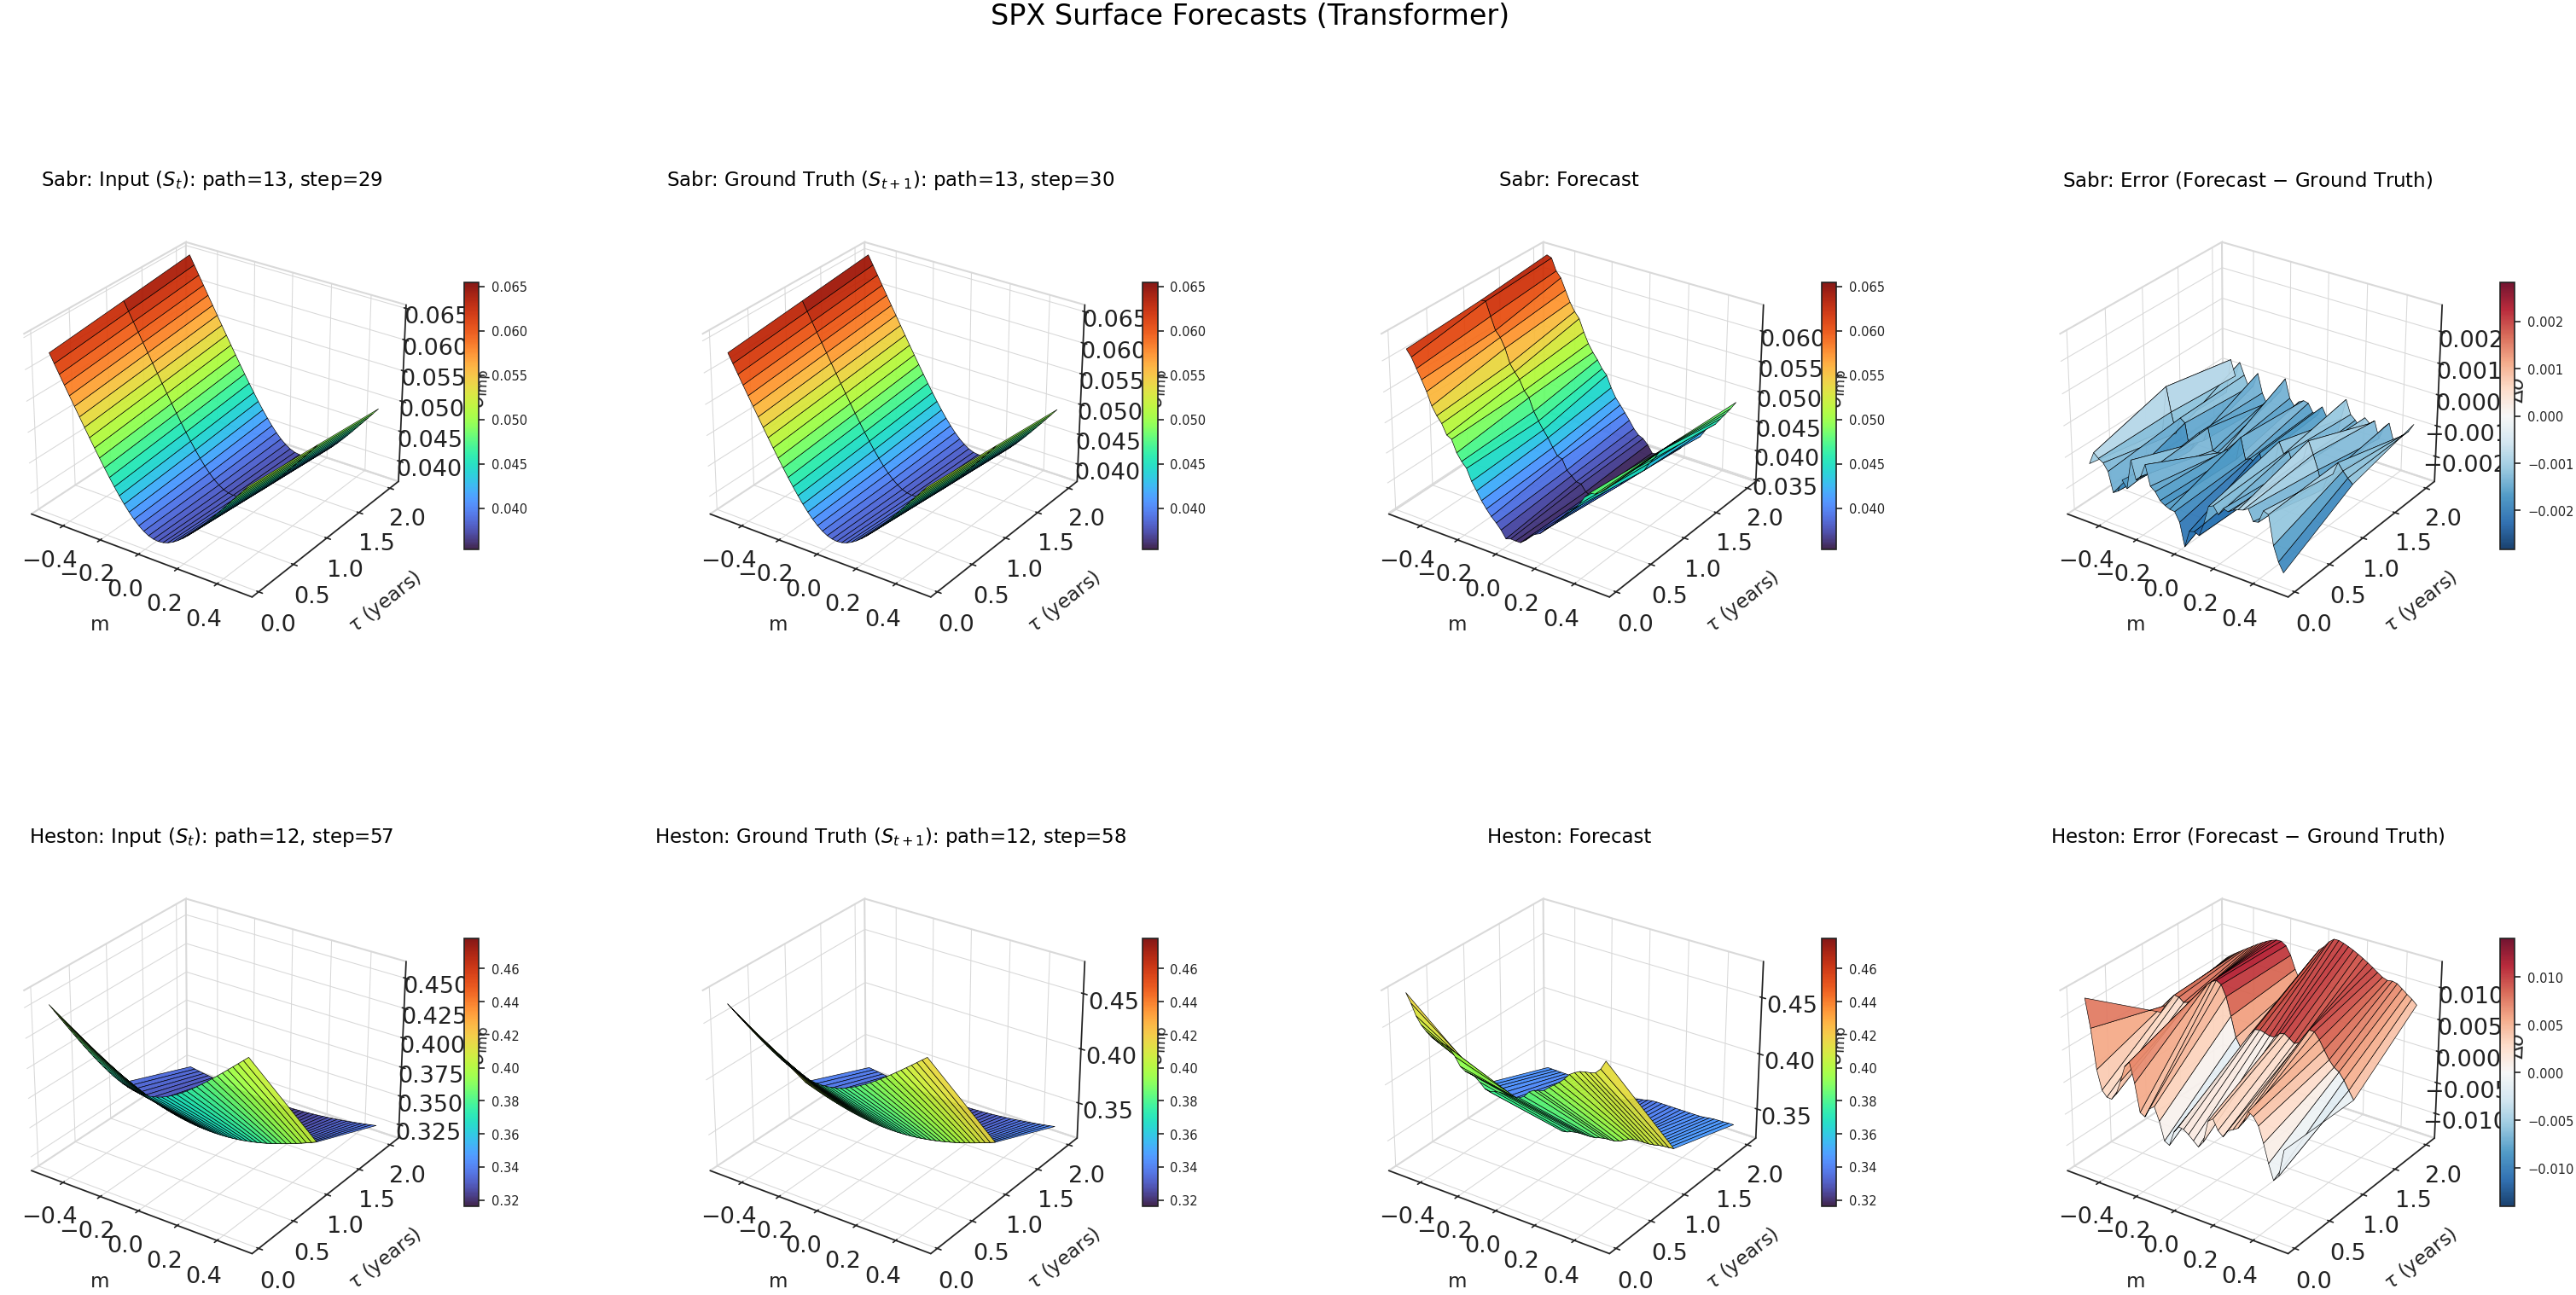

In [11]:
m_axis = np.asarray(GRID.log_moneyness, dtype=np.float64)
tau_axis = np.asarray(GRID.tau, dtype=np.float64)
MM_5, TT_5 = np.meshgrid(m_axis, tau_axis[tenor_idx], indexing="ij")

_VALIDATION_PDF_GROUPS = (
    ("historical", [inst for inst in display_instances if inst["path_type"] == "historical"]),
    ("synthetic", [inst for inst in display_instances if inst["path_type"] != "historical"]),
)

for _pdf_group_label, _group_instances in _VALIDATION_PDF_GROUPS:
    if not _group_instances:
        continue
    n_instances = len(_group_instances)

    with rc_context():
        fig3d = plt.figure(figsize=(26.0, 5.8 * n_instances))
        fig3d.patch.set_facecolor(plt.rcParams["figure.facecolor"])
        fig3d.subplots_adjust(wspace=0.25, hspace=0.35)

        for row, inst in enumerate(_group_instances):
            path_label = inst["path_type"].capitalize()
            panels = [
                (inst["input"], f"Input ($S_t$): {inst['input_label']}", SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
                (
                    inst["ground_truth"],
                    f"Ground Truth ($S_{{t+1}}$): {inst['gt_label']}",
                    SURF_CMAP,
                    r"$\sigma_{\mathrm{imp}}$",
                    False,
                ),
                (inst["forecast"], "Forecast", SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
                (
                    inst["forecast"] - inst["ground_truth"],
                    "Error (Forecast $-$ Ground Truth)",
                    DIFF_CMAP,
                    r"$\Delta\sigma$",
                    True,
                ),
            ]

            all_iv_vals = np.concatenate(
                [
                    inst["input"][:, tenor_idx].ravel(),
                    inst["ground_truth"][:, tenor_idx].ravel(),
                    inst["forecast"][:, tenor_idx].ravel(),
                ]
            )
            shared_vmin = float(np.nanmin(all_iv_vals))
            shared_vmax = float(np.nanmax(all_iv_vals))
            if (not np.isfinite(shared_vmin)) or (not np.isfinite(shared_vmax)) or shared_vmin == shared_vmax:
                shared_vmin, shared_vmax = 0.0, 1.0

            for col, (iv, title, cmap, zlabel, is_diff) in enumerate(panels):
                ax = fig3d.add_subplot(n_instances, 4, 4 * row + col + 1, projection="3d")
                iv_5 = iv[:, tenor_idx]
                if is_diff:
                    panel_abs = float(np.nanmax(np.abs(iv_5)))
                    if not np.isfinite(panel_abs) or panel_abs == 0.0:
                        panel_abs = 1.0
                    vmin_, vmax_ = -panel_abs, panel_abs
                    ax.set_zlim(vmin_, vmax_)
                else:
                    vmin_, vmax_ = shared_vmin, shared_vmax

                plotted = ax.plot_surface(
                    MM_5,
                    TT_5,
                    iv_5,
                    cmap=cmap,
                    vmin=vmin_,
                    vmax=vmax_,
                    linewidth=0.3,
                    edgecolor="k",
                    alpha=0.92,
                    antialiased=True,
                    rstride=1,
                    cstride=1,
                )
                ax.set_title(f"{path_label}: {title}", fontsize=11, pad=12)
                ax.set_xlabel(r"m", labelpad=8)
                ax.set_ylabel(r"$\tau$ (years)", labelpad=10)
                ax.set_zlabel(zlabel, labelpad=6)
                ax.view_init(elev=28, azim=-55)
                ax.tick_params(pad=2)
                style_3d_axes(ax)
                ax.xaxis.pane.set_edgecolor("0.85")
                ax.yaxis.pane.set_edgecolor("0.85")
                ax.zaxis.pane.set_edgecolor("0.85")
                cbar = fig3d.colorbar(plotted, ax=ax, shrink=0.55, pad=0.08, aspect=18)
                cbar.ax.tick_params(labelsize=7)

        fig3d.suptitle("SPX Surface Forecasts (Transformer)", fontsize=16, y=0.995)
        fig3d.savefig(
            f"trans_validation_input_ground_truth_forecast_difference_3d_{_pdf_group_label}.pdf",
            format="pdf",
            bbox_inches="tight",
        )
        plt.show()

## Forecast: unrepaired vs repaired (metrics + 3D)

Compares **raw DDIM** forecasts to **VolGAN-repaired** forecasts on the validation instances.

,instance,path_type,pair_idx,seed,raw_arb_free,repaired_arb_free,raw_rmse_vs_gt,repaired_rmse_vs_gt,rmse_delta_repaired_minus_raw,raw_mae_vs_gt,repaired_mae_vs_gt,raw_mape_pct_vs_gt,repaired_mape_pct_vs_gt,repair_rmse,repair_mae,repair_max_abs,raw_worst_butterfly,raw_worst_calendar,repaired_worst_butterfly,repaired_worst_calendar
0,1,historical,0,9042,False,True,0.021085,0.021805,0.000720,0.019700,0.020781,8.476178,9.189458,0.005915,0.003279,0.046657,-0.232362,-0.011520,-3.780959e-15,-4.078545e-05
1,2,historical,1,9043,False,True,0.009691,0.010146,0.000456,0.008417,0.009190,3.629182,4.137165,0.005525,0.002955,0.045876,-0.192627,-0.012624,-3.780959e-15,-9.737218e-06
2,3,historical,2,9044,False,True,0.018777,0.019796,0.001019,0.017183,0.018300,7.710863,8.359136,0.005216,0.003064,0.042000,-0.193056,-0.009482,-3.780959e-15,-4.991094e-05
3,4,historical,3,9045,False,True,0.010224,0.010970,0.000746,0.009121,0.010065,4.090825,4.659182,0.005335,0.003097,0.038929,-0.212580,-0.008987,-7.561918e-15,-2.171800e-05
4,5,historical,4,9046,False,True,0.019425,0.019543,0.000117,0.014334,0.015237,5.962447,6.596194,0.005150,0.003090,0.043285,-0.181615,-0.007856,-3.780959e-15,-4.724593e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,247,historical,246,9288,False,True,0.014405,0.014552,0.000148,0.012220,0.013229,6.124164,6.965572,0.005833,0.003390,0.043486,-0.213049,-0.008209,-7.015520e-15,-9.152064e-05
247,248,historical,247,9289,False,True,0.004363,0.007367,0.003004,0.003088,0.004399,1.576995,2.422033,0.006492,0.003734,0.057334,-0.249776,-0.014162,-3.780959e-15,-7.621679e-05
248,249,historical,248,9290,False,True,0.008444,0.009540,0.001095,0.004819,0.005690,2.116688,2.718134,0.005722,0.003262,0.054124,-0.147606,-0.010058,-6.508603e-15,-5.488529e-05
249,250,sabr,29,29071,False,True,0.001543,0.001475,-0.000068,0.001409,0.001405,3.134795,3.117527,0.000270,0.000214,0.001200,-0.000004,-0.000302,-1.607701e-11,-8.673617e-19


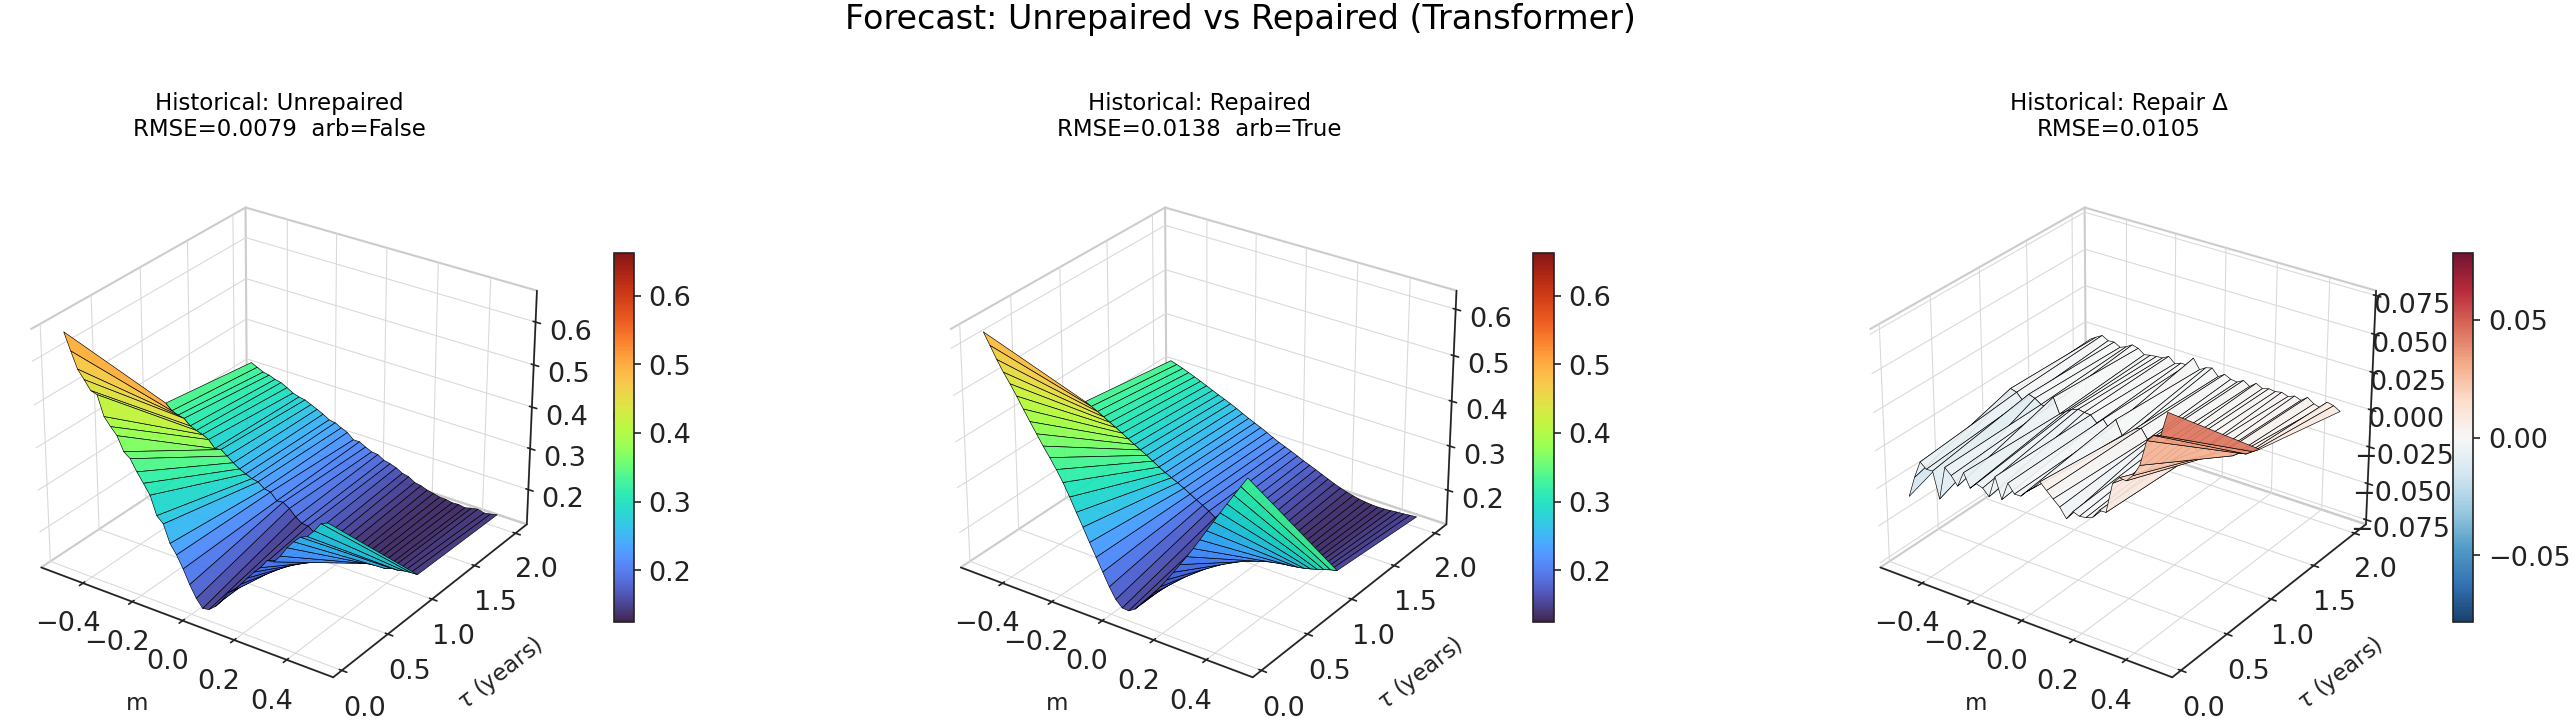

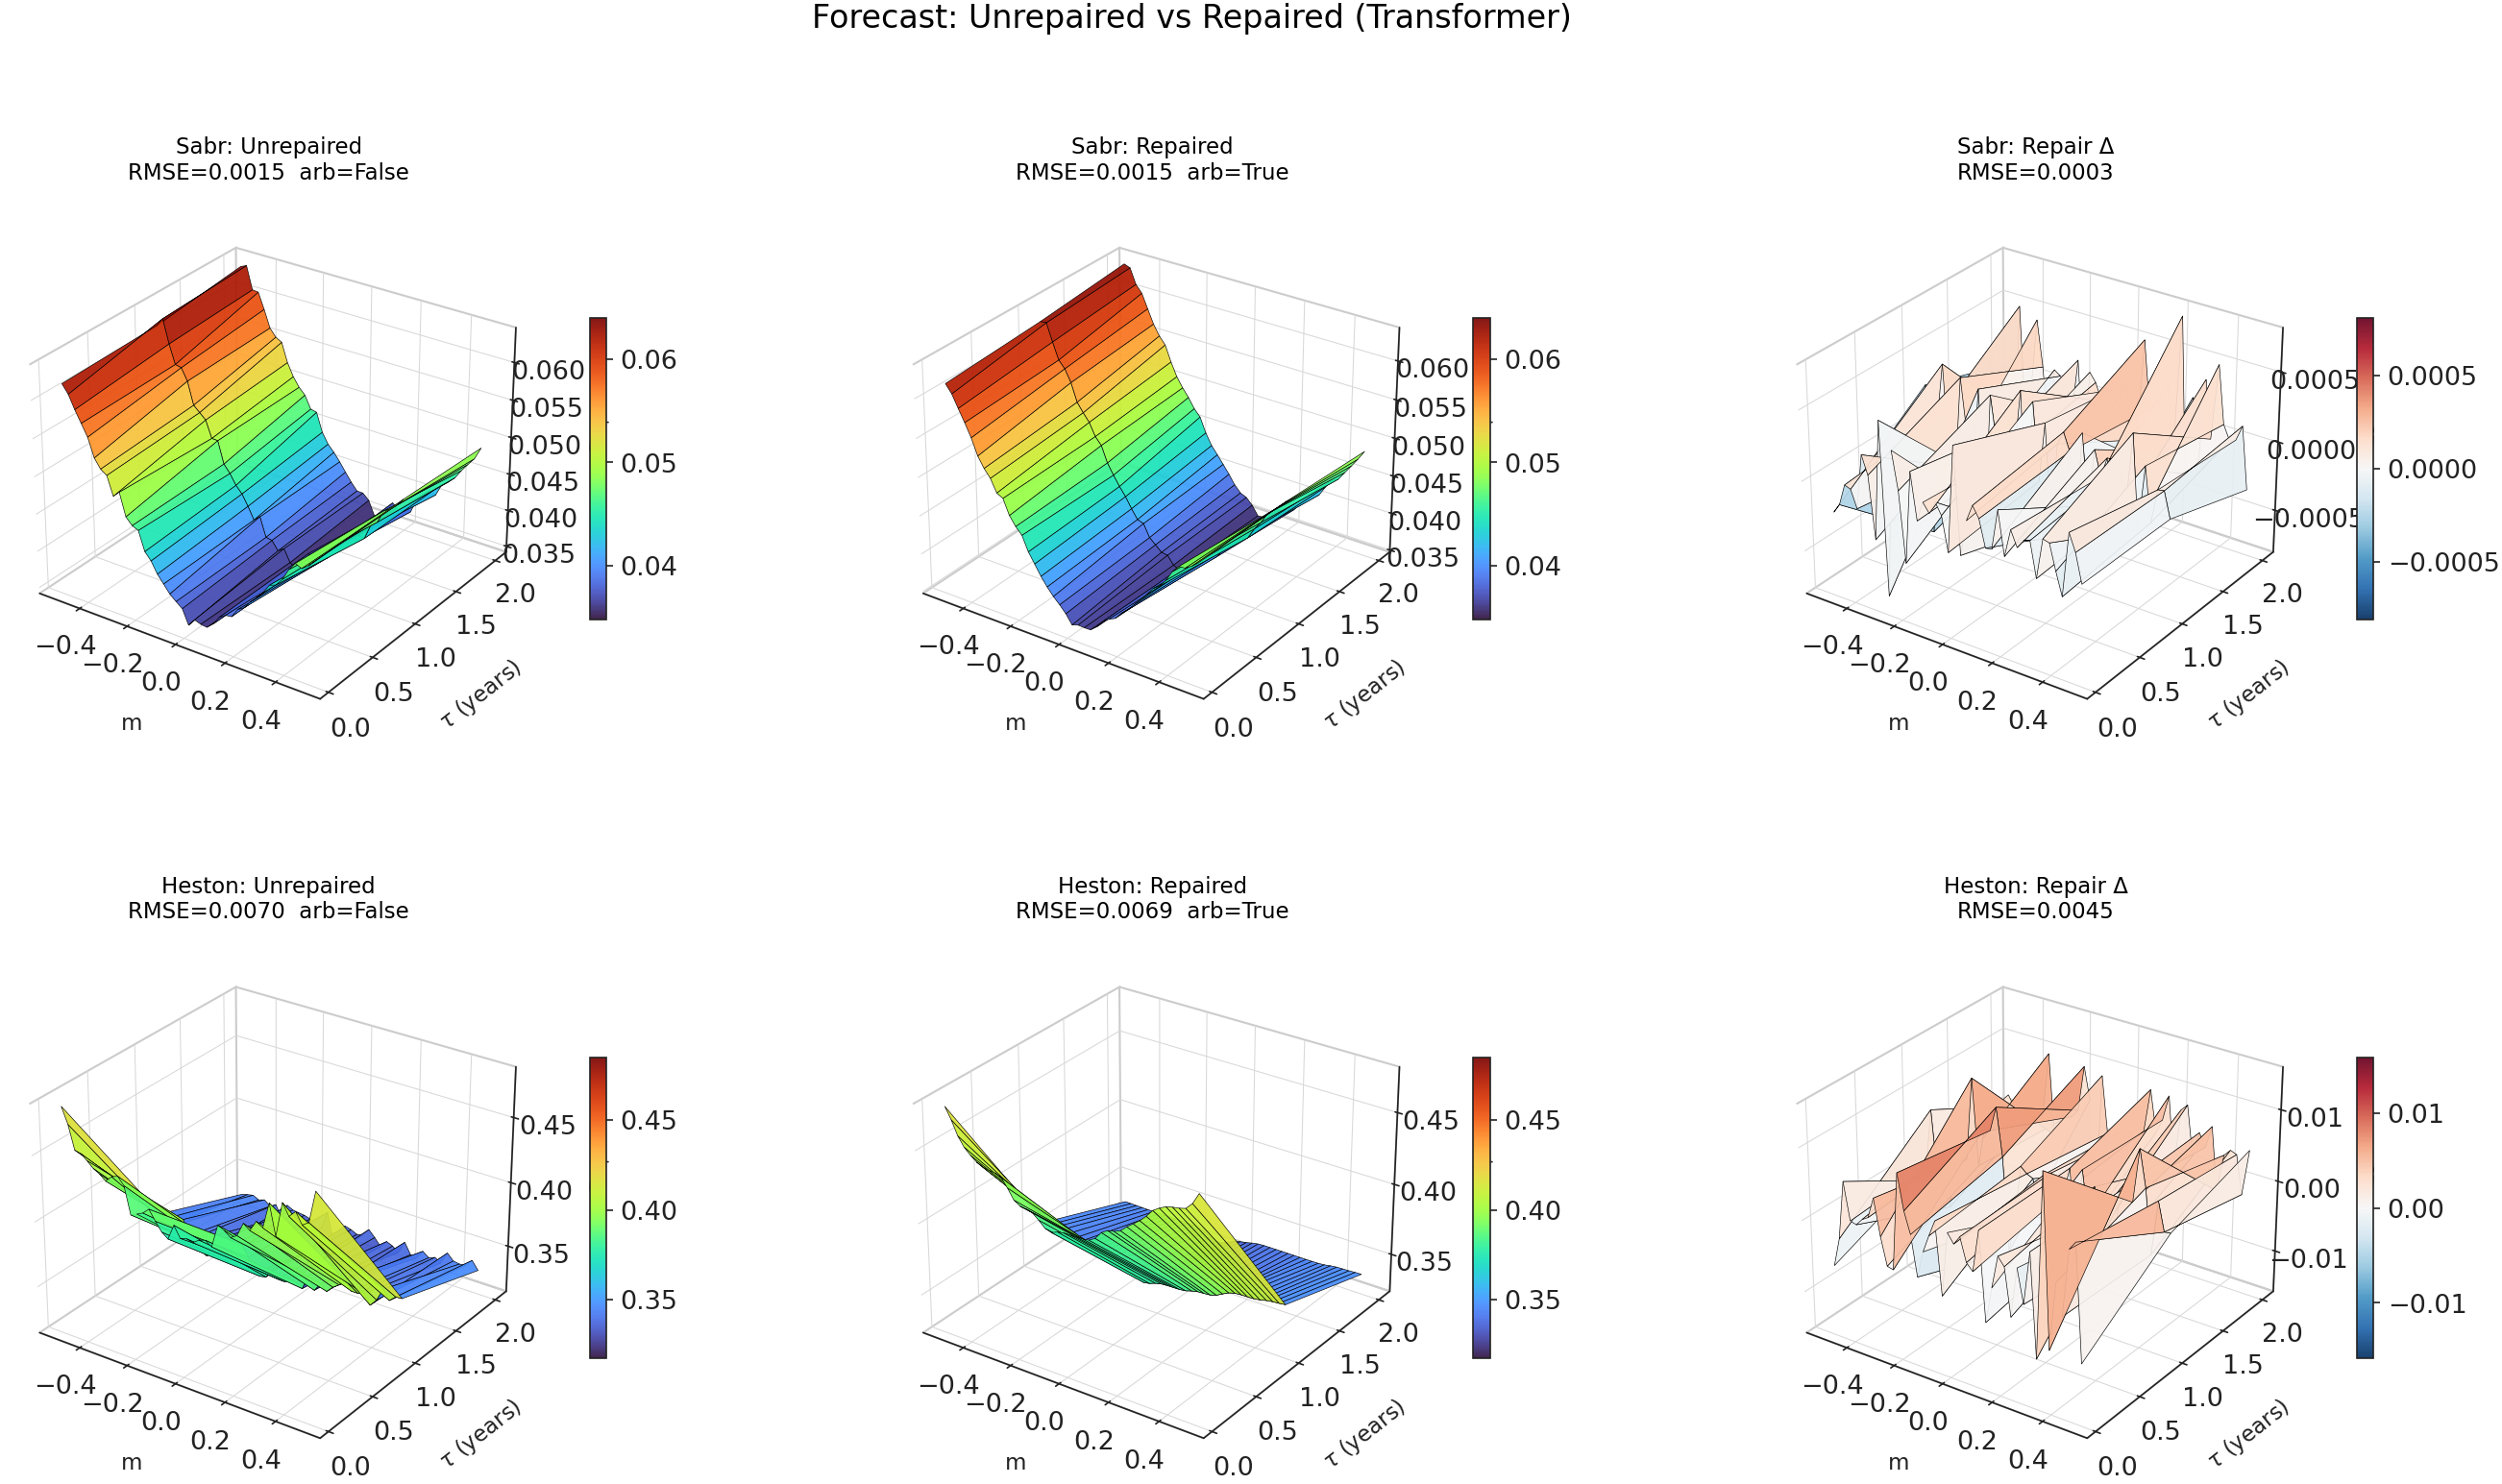

In [12]:
display(forecast_repair_metrics_df)

m_axis = np.asarray(GRID.log_moneyness, dtype=np.float64)
tau_axis = np.asarray(GRID.tau, dtype=np.float64)
MM_5, TT_5 = np.meshgrid(m_axis, tau_axis[tenor_idx], indexing="ij")

_VALIDATION_PDF_GROUPS = (
    ("historical", [inst for inst in display_instances if inst["path_type"] == "historical"]),
    ("synthetic", [inst for inst in display_instances if inst["path_type"] != "historical"]),
)
for _pdf_group_label, _group_instances in _VALIDATION_PDF_GROUPS:
    if not _group_instances:
        continue
    n_instances = len(_group_instances)

    with rc_context():
        fig3d = plt.figure(figsize=(22.0, 5.8 * n_instances))
        fig3d.patch.set_facecolor(plt.rcParams["figure.facecolor"])
        fig3d.subplots_adjust(wspace=0.28, hspace=0.35)

        for row, inst in enumerate(_group_instances):
            fc_raw = np.asarray(inst["forecast_raw"], dtype=np.float64)
            fc_rep = np.asarray(inst["forecast"], dtype=np.float64)
            repair_delta = fc_rep - fc_raw
            path_label = inst["path_type"].capitalize()
            raw_arb = bool(inst["meta"].get("forecast_raw_arb_free", False))
            rep_arb = bool(inst["meta"]["forecast_arb_free"])
            mrow = forecast_repair_metrics_df[
                (forecast_repair_metrics_df["path_type"] == inst["path_type"])
                & (forecast_repair_metrics_df["pair_idx"] == int(inst["pair_idx"]))
            ].iloc[0]

            panels = [
                (
                    fc_raw,
                    f"Unrepaired\nRMSE={mrow['raw_rmse_vs_gt']:.4f}  arb={raw_arb}",
                    SURF_CMAP,
                    r"$\sigma_{\mathrm{imp}}$",
                    False,
                ),
                (
                    fc_rep,
                    f"Repaired\nRMSE={mrow['repaired_rmse_vs_gt']:.4f}  arb={rep_arb}",
                    SURF_CMAP,
                    r"$\sigma_{\mathrm{imp}}$",
                    False,
                ),
                (repair_delta, f"Repair \u0394\nRMSE={mrow['repair_rmse']:.4f}", DIFF_CMAP, r"$\Delta\sigma$", True),
            ]

            all_iv_vals = np.concatenate([fc_raw[:, tenor_idx].ravel(), fc_rep[:, tenor_idx].ravel()])
            shared_vmin = float(np.nanmin(all_iv_vals))
            shared_vmax = float(np.nanmax(all_iv_vals))
            if (not np.isfinite(shared_vmin)) or (not np.isfinite(shared_vmax)) or shared_vmin == shared_vmax:
                shared_vmin, shared_vmax = 0.0, 1.0

            for col, (iv, title, cmap, zlabel, is_diff) in enumerate(panels):
                ax = fig3d.add_subplot(n_instances, 3, 3 * row + col + 1, projection="3d")
                iv_5 = iv[:, tenor_idx]
                if is_diff:
                    panel_abs = float(np.nanmax(np.abs(iv_5)))
                    if not np.isfinite(panel_abs) or panel_abs == 0.0:
                        panel_abs = 1.0
                    vmin_, vmax_ = -panel_abs, panel_abs
                    ax.set_zlim(vmin_, vmax_)
                else:
                    vmin_, vmax_ = shared_vmin, shared_vmax

                plotted = ax.plot_surface(
                    MM_5,
                    TT_5,
                    iv_5,
                    cmap=cmap,
                    vmin=vmin_,
                    vmax=vmax_,
                    linewidth=0.3,
                    edgecolor="k",
                    alpha=0.92,
                    antialiased=True,
                    rstride=1,
                    cstride=1,
                )
                ax.set_title(f"{path_label}: {title}", fontsize=11, pad=12)
                ax.set_xlabel(r"m", labelpad=8)
                ax.set_ylabel(r"$\tau$ (years)", labelpad=10)
                ax.set_zlabel(zlabel, labelpad=6)
                ax.view_init(elev=28, azim=-55)
                ax.tick_params(pad=2)
                style_3d_axes(ax)
                fig3d.colorbar(plotted, ax=ax, shrink=0.55, pad=0.08, aspect=18)

        fig3d.suptitle("Forecast: Unrepaired vs Repaired (Transformer)", fontsize=16, y=0.995)
        fig3d.savefig(
            f"trans_validation_heatmap_ground_truth_vs_forecast_{_pdf_group_label}.pdf",
            format="pdf",
            bbox_inches="tight",
        )
        plt.show()

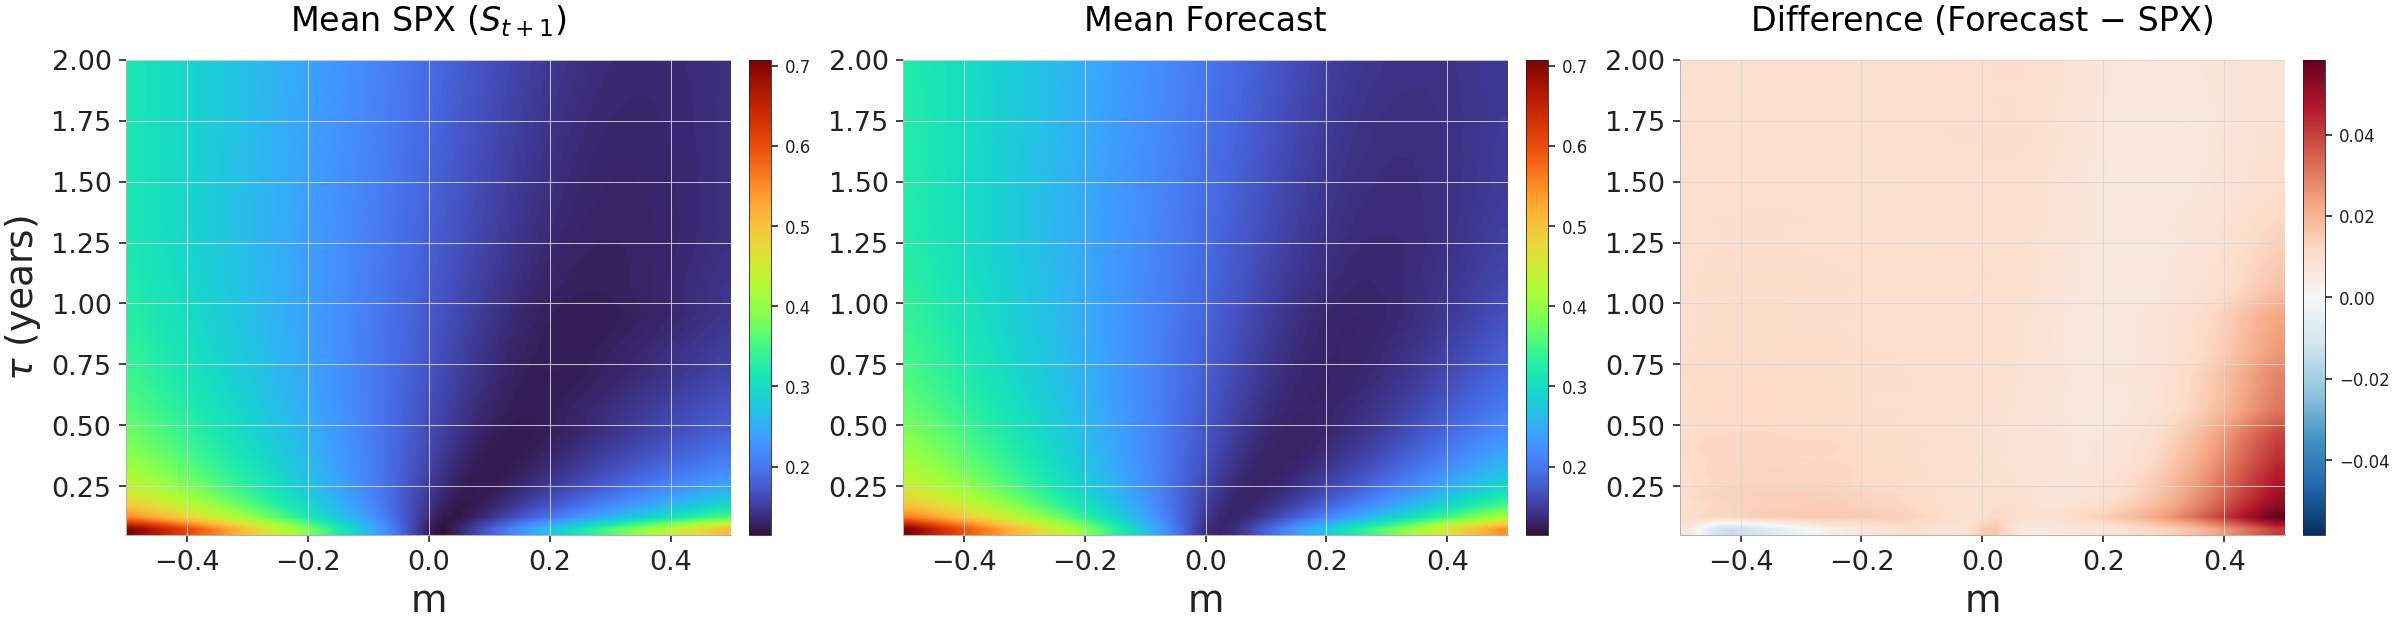

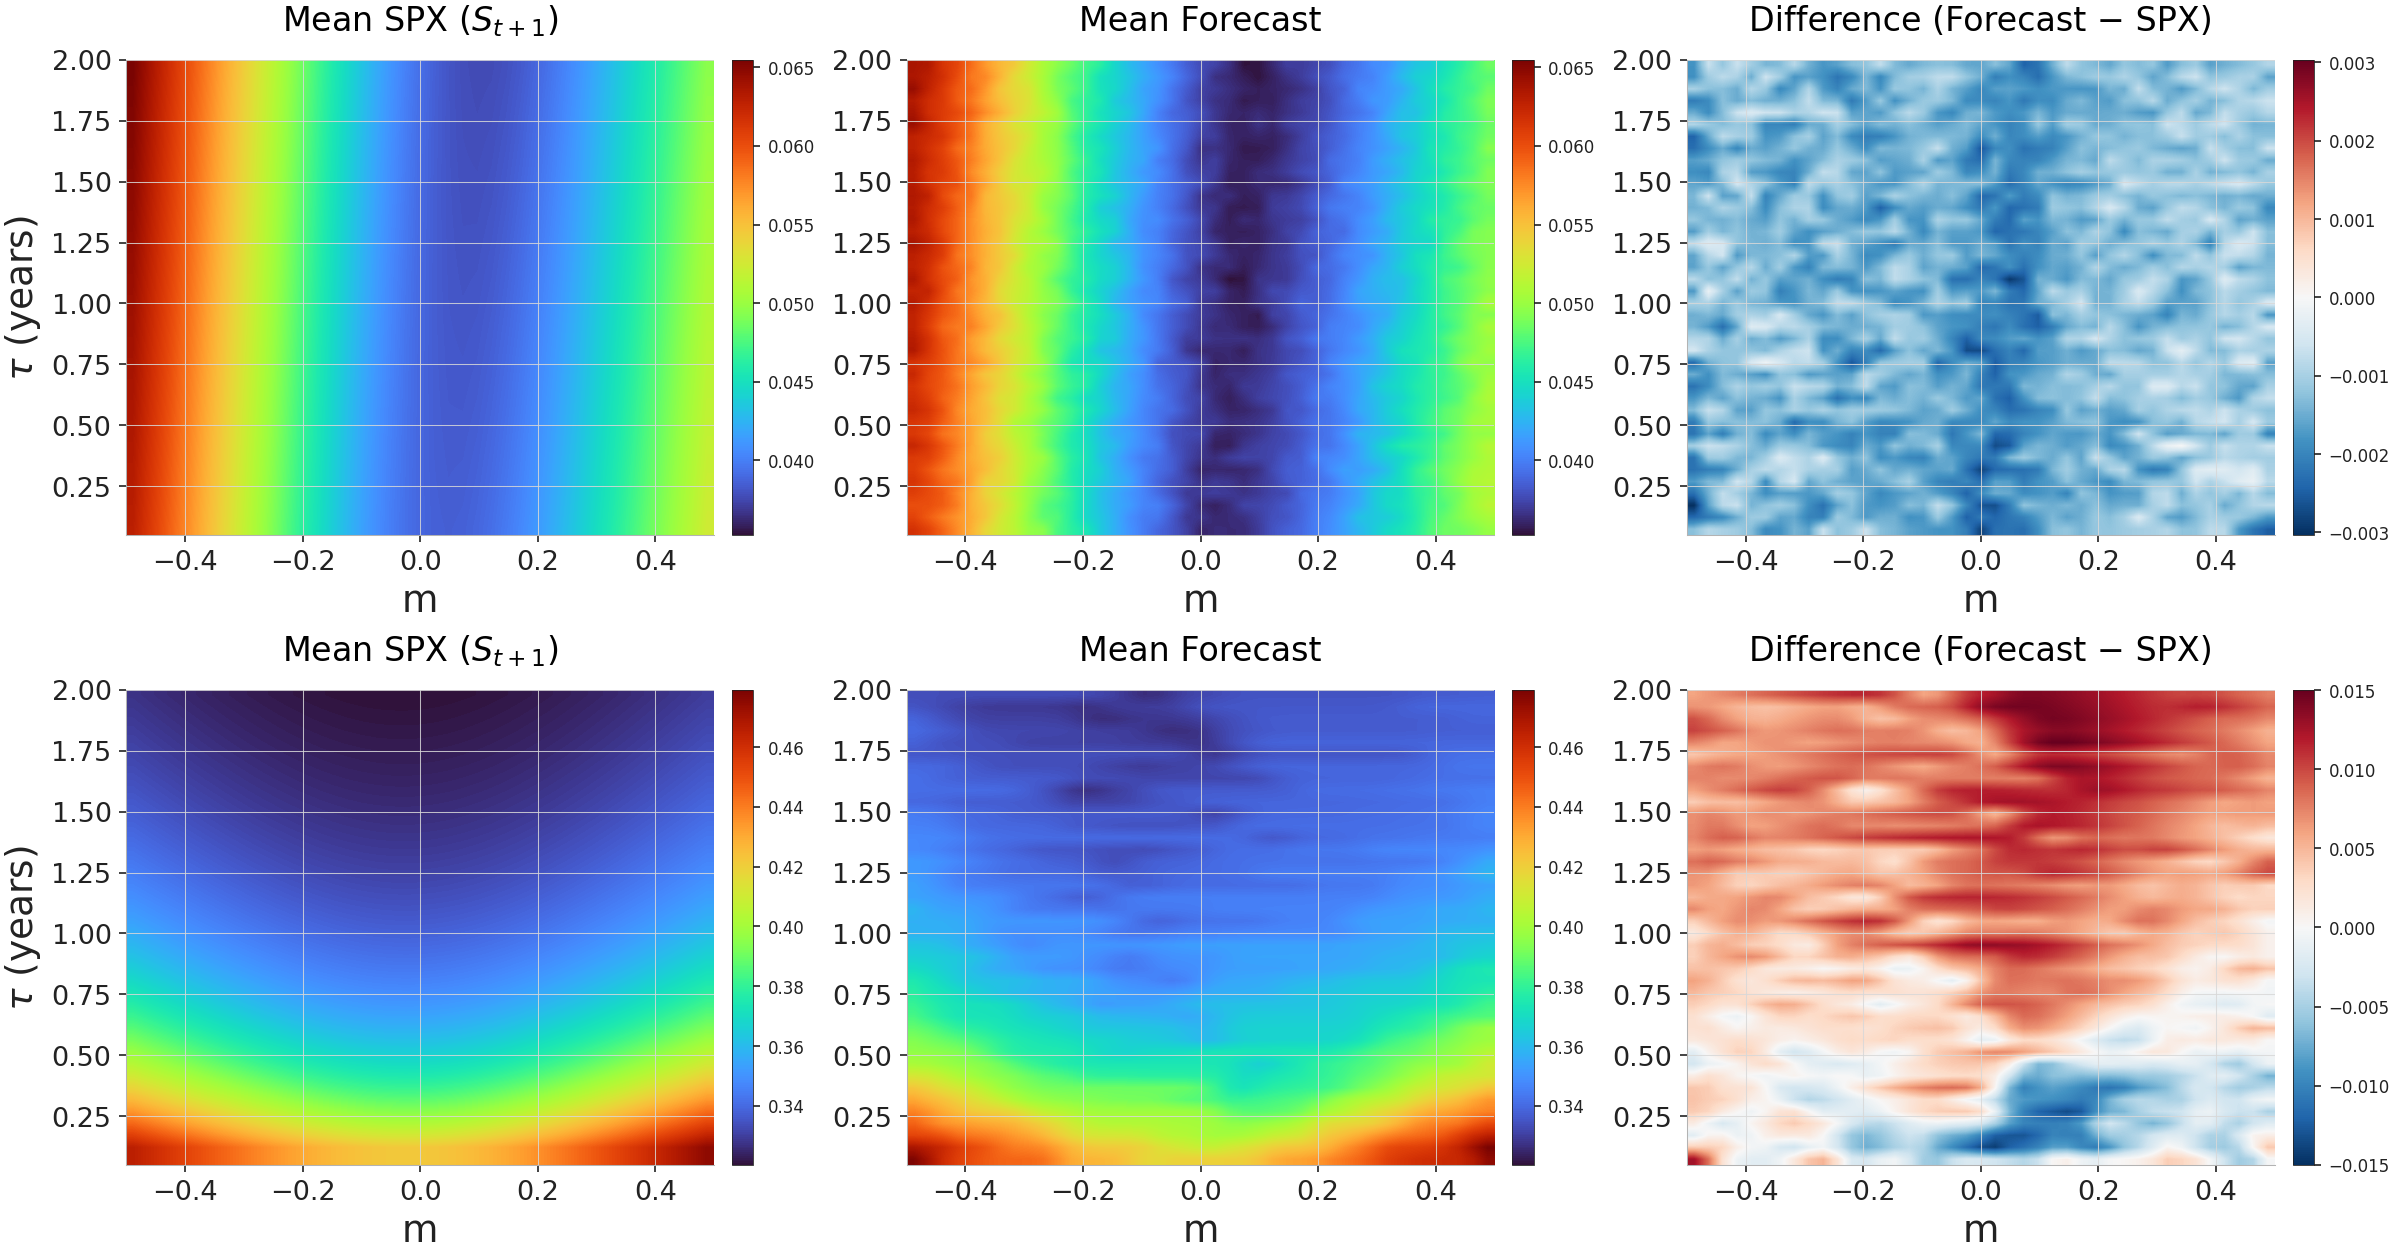

In [13]:
_hist_insts = [inst for inst in instances if inst["path_type"] == "historical"]
_synth_insts = [inst for inst in display_instances if inst["path_type"] != "historical"]

_heatmap_groups = []
if _hist_insts:
    mean_gt = np.nanmean(np.stack([inst["ground_truth"] for inst in _hist_insts]), axis=0)
    mean_fc = np.nanmean(np.stack([inst["forecast"] for inst in _hist_insts]), axis=0)
    _heatmap_groups.append(("historical", [{"ground_truth": mean_gt, "forecast": mean_fc,
        "path_type": "historical", "gt_label": f"mean over {len(_hist_insts)} pairs",
        "input_label": f"mean over {len(_hist_insts)} pairs"}]))
if _synth_insts:
    _heatmap_groups.append(("synthetic", _synth_insts))

for _pdf_group_label, _group_instances in _heatmap_groups:
    if not _group_instances:
        continue
    n_instances = len(_group_instances)

    with rc_context():
        fig_hm, axes_hm = plt.subplots(
            n_instances,
            3,
            figsize=(16.0, 4.2 * n_instances),
            squeeze=False,
            constrained_layout=True,
        )
        fig_hm.patch.set_facecolor(plt.rcParams["figure.facecolor"])

        for row, inst in enumerate(_group_instances):
            gt = np.asarray(inst["ground_truth"], dtype=float)
            fc = np.asarray(inst["forecast"], dtype=float)
            err = fc - gt
            path_label = inst["path_type"].capitalize()

            shared_vmin = min(float(np.nanmin(gt)), float(np.nanmin(fc)))
            shared_vmax = max(float(np.nanmax(gt)), float(np.nanmax(fc)))
            if (not np.isfinite(shared_vmin)) or (not np.isfinite(shared_vmax)) or shared_vmin == shared_vmax:
                shared_vmin, shared_vmax = 0.0, 1.0

            gt_title = (f"Mean SPX ($S_{{t+1}}$, n={len(_hist_insts)})"
                        if inst["path_type"] == "historical"
                        else f"Ground Truth ($S_{{t+1}}$): {inst['gt_label']}")
            fc_title = (f"Mean Forecast (n={len(_hist_insts)})"
                        if inst["path_type"] == "historical"
                        else "Forecast")
            panels = [
                (gt, r"Mean SPX ($S_{t+1}$)", SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
                (fc, "Mean Forecast", SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
                (err, "Difference (Forecast − SPX)", DIFF_CMAP, r"$\Delta\sigma$", True),
            ]

            for col, (mat, ttl, cmap, cbar_label, is_diff) in enumerate(panels):
                ax = axes_hm[row, col]
                for spine in ax.spines.values():
                    spine.set_visible(True)
                    spine.set_color("0.7")
                    spine.set_linewidth(0.5)

                if is_diff:
                    panel_abs = float(np.nanmax(np.abs(mat)))
                    if not np.isfinite(panel_abs) or panel_abs == 0.0:
                        panel_abs = 1.0
                    vmin_, vmax_ = -panel_abs, panel_abs
                else:
                    vmin_, vmax_ = shared_vmin, shared_vmax

                image = ax.imshow(
                    mat.T,
                    origin="lower",
                    aspect="auto",
                    extent=(m_axis[0], m_axis[-1], tau_axis[0], tau_axis[-1]),
                    cmap=cmap,
                    vmin=vmin_,
                    vmax=vmax_,
                    interpolation="bilinear",
                )
                ax.set_title(f"{ttl}", fontsize=16, pad=14)
                ax.set_xlabel(r"m", fontsize=18)
                ax.set_ylabel(r"$\tau$ (years)" if col == 0 else "", fontsize=18)
                ax.tick_params(direction="out")
                style_2d_axes(ax)
                cbar = fig_hm.colorbar(image, ax=ax, fraction=0.046, pad=0.03, aspect=22)
                cbar.ax.tick_params(labelsize=8)
                cbar.outline.set_linewidth(0.4)
        fig_hm.savefig(
            f"trans_validation_heatmap_gt_vs_forecast_{_pdf_group_label}.pdf",
            format="pdf",
            bbox_inches="tight",
        )
        plt.show()


## Cross-section at selected tenors

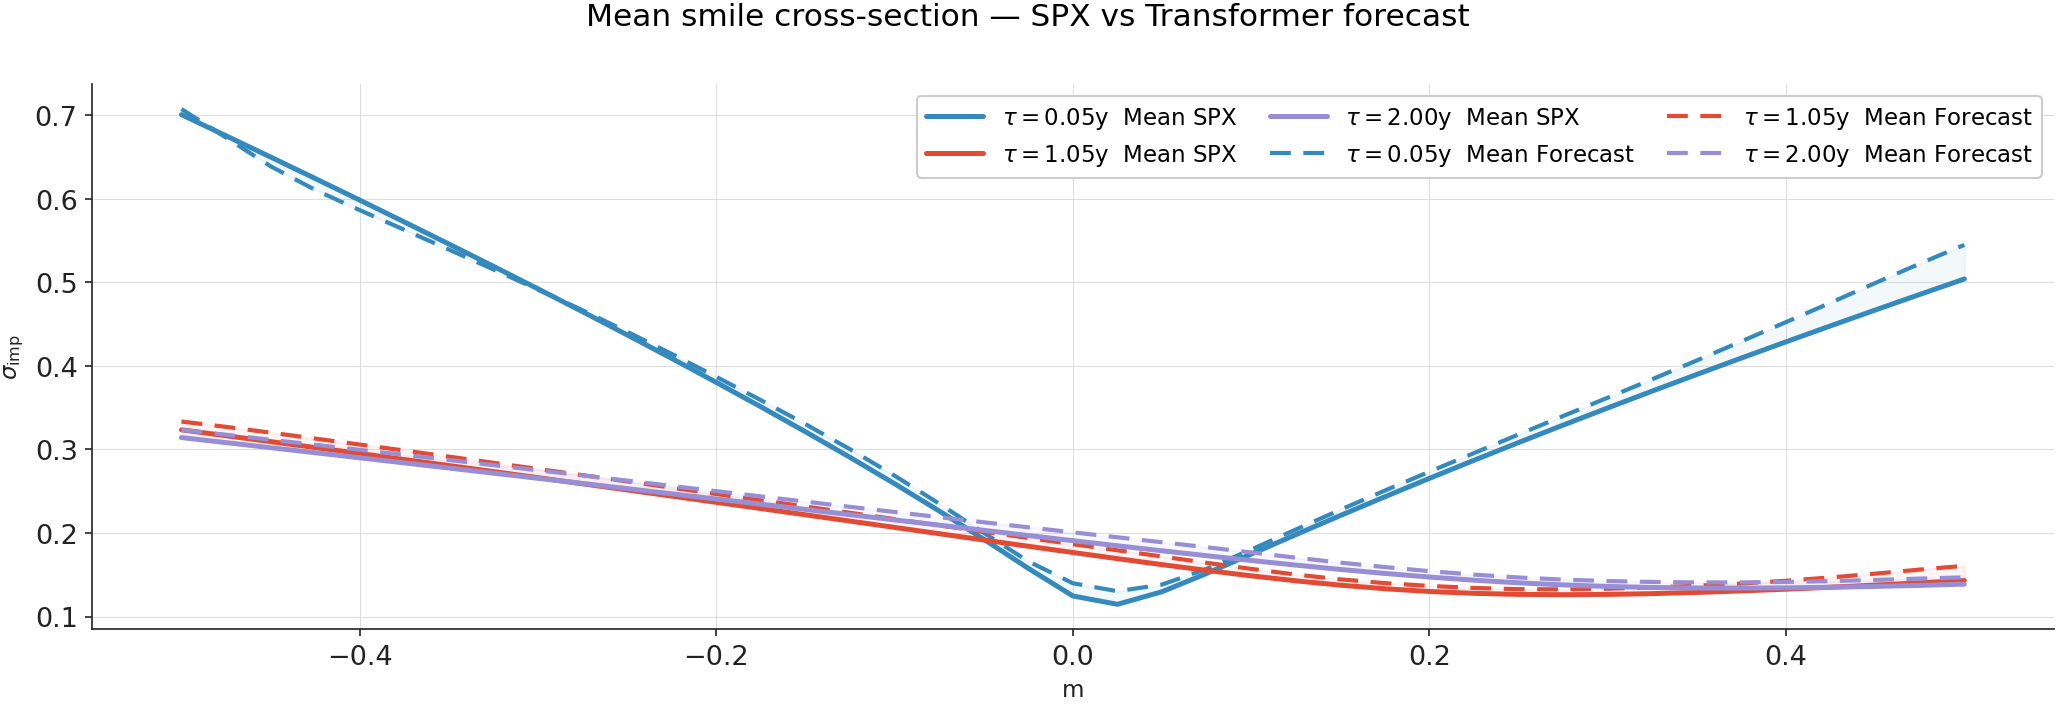

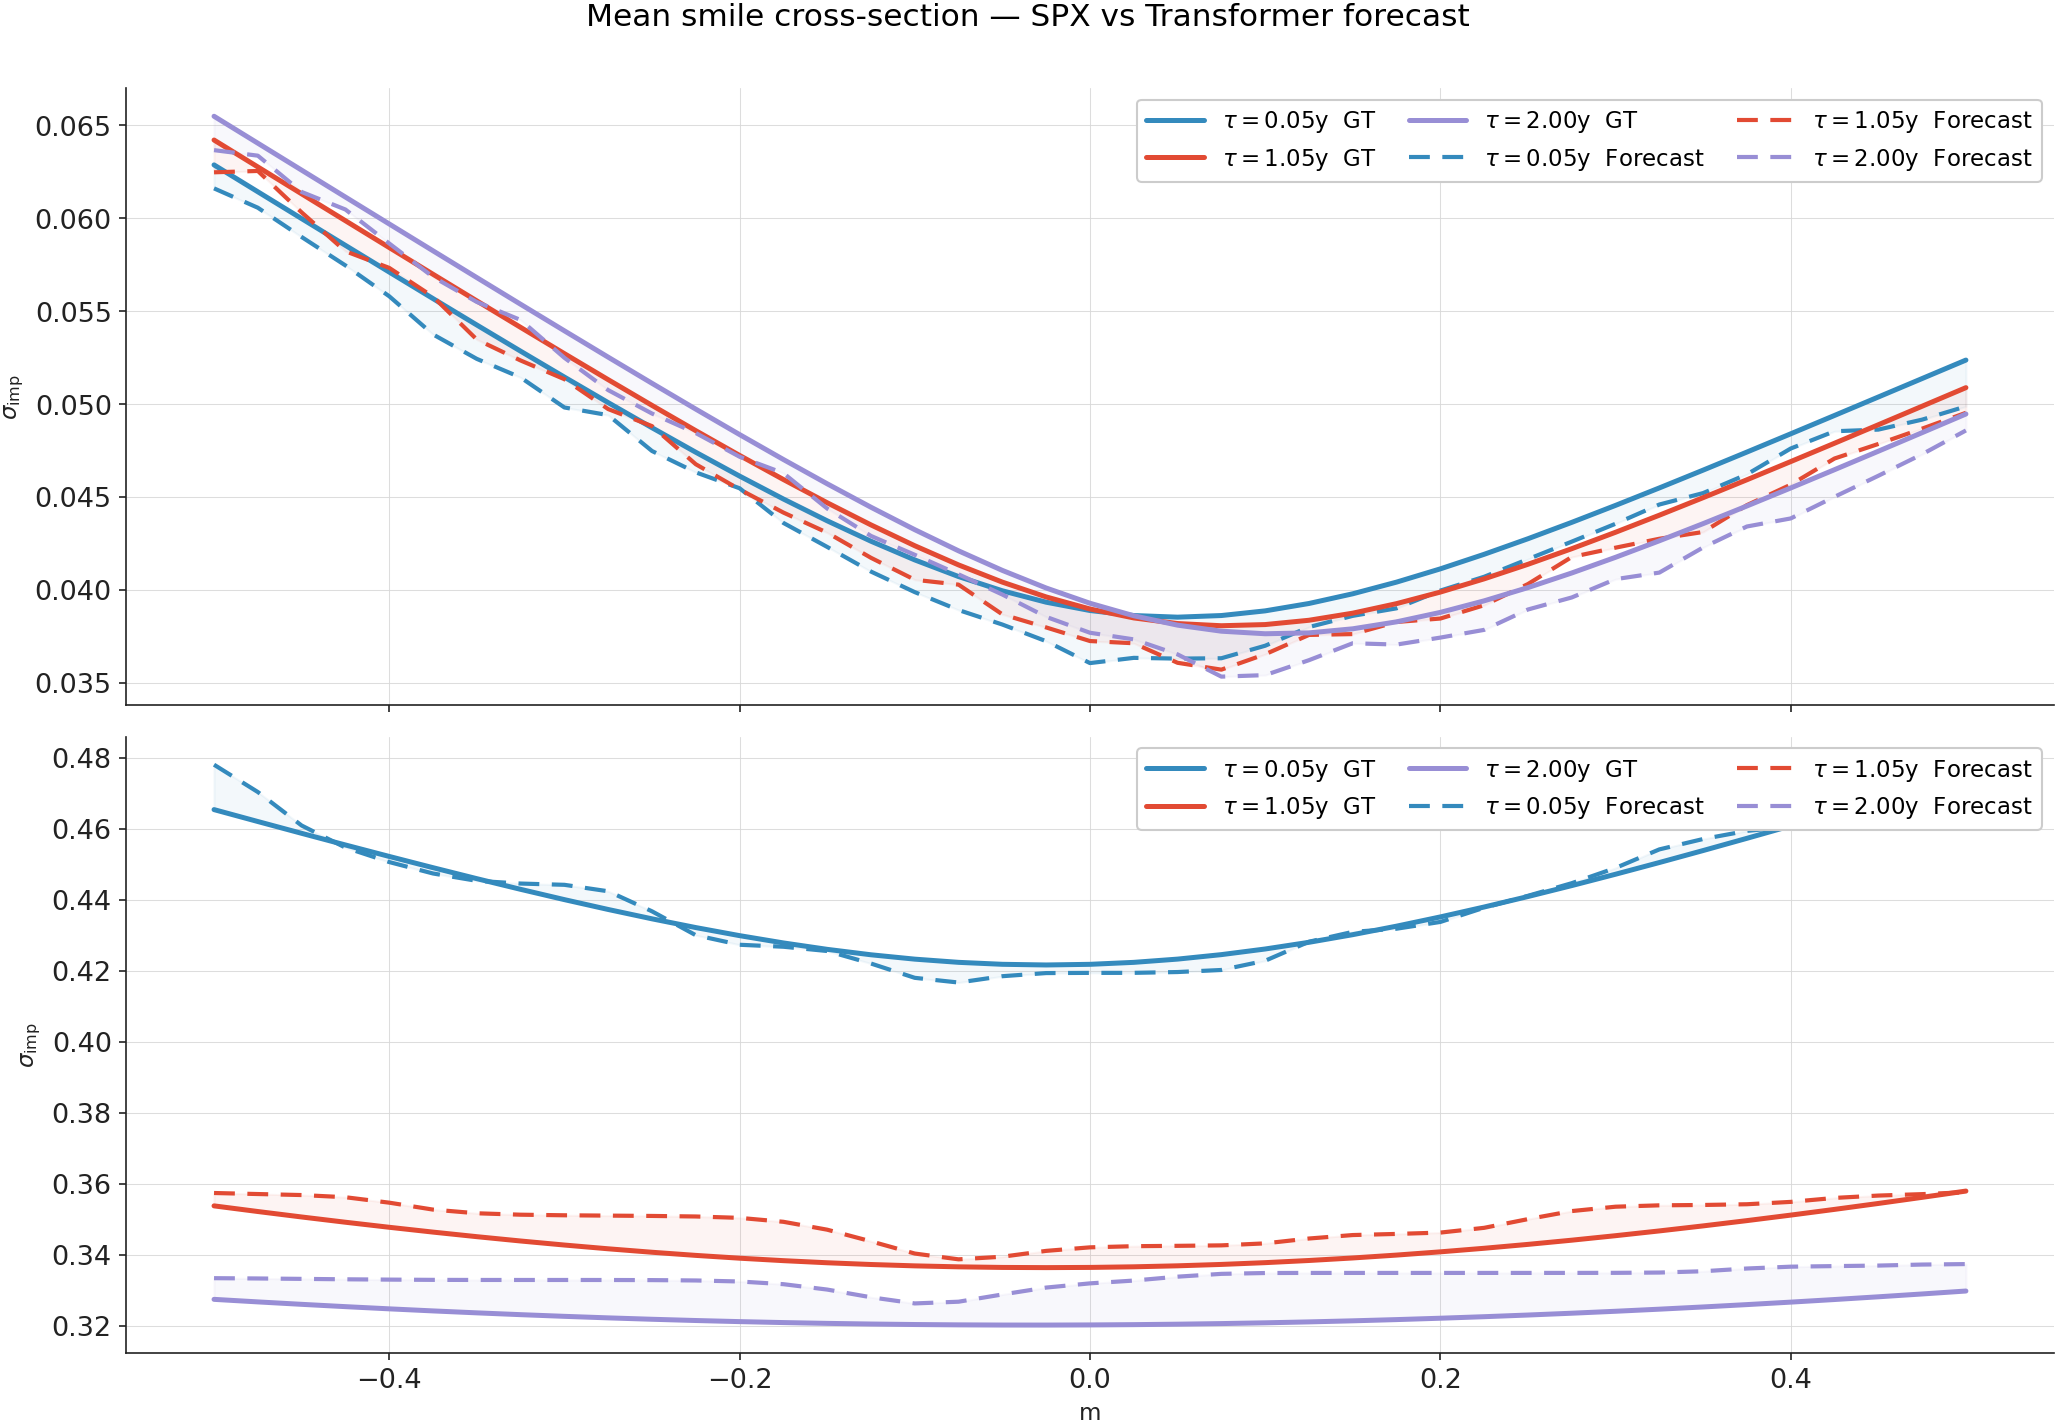

In [20]:
_hist_insts = [inst for inst in instances if inst["path_type"] == "historical"]
_synth_insts = [inst for inst in display_instances if inst["path_type"] != "historical"]

_xsection_groups = []
if _hist_insts:
    mean_gt = np.nanmean(np.stack([inst["ground_truth"] for inst in _hist_insts]), axis=0)
    mean_fc = np.nanmean(np.stack([inst["forecast"] for inst in _hist_insts]), axis=0)
    _xsection_groups.append(("historical", [{"ground_truth": mean_gt, "forecast": mean_fc,
        "path_type": "historical", "gt_label": f"mean (n={len(_hist_insts)})",
        "input_label": f"mean (n={len(_hist_insts)})"}]))
if _synth_insts:
    _xsection_groups.append(("synthetic", _synth_insts))

for _pdf_group_label, _group_instances in _xsection_groups:
    if not _group_instances:
        continue
    n_instances = len(_group_instances)

    with rc_context():
        fig, axes = plt.subplots(
            n_instances,
            1,
            figsize=(14, 4.8 * n_instances),
            squeeze=False,
            sharex="col",
        )
        fig.patch.set_facecolor(plt.rcParams["figure.facecolor"])

        for row, inst in enumerate(_group_instances):
            ax = axes[row, 0]
            gt_iv = inst["ground_truth"]
            fc_iv = inst["forecast"]
            path_label = inst["path_type"].capitalize()

            for j, tidx in enumerate(tenor_idx):
                color = TENOR_COLORS[j % len(TENOR_COLORS)]
                tenor_label = rf"$\tau = {tau_axis[tidx]:.2f}$y"
                gt_lbl = f"{tenor_label}  Mean SPX" if inst["path_type"] == "historical" else f"{tenor_label}  GT"
                fc_lbl = f"{tenor_label}  Mean Forecast" if inst["path_type"] == "historical" else f"{tenor_label}  Forecast"
                ax.plot(m_axis, gt_iv[:, tidx], color=color, lw=2.4, solid_capstyle="round", label=gt_lbl)
                ax.plot(
                    m_axis,
                    fc_iv[:, tidx],
                    color=color,
                    lw=2.0,
                    ls="--",
                    dashes=(5, 3),
                    label=fc_lbl,
                )
                ax.fill_between(m_axis, gt_iv[:, tidx], fc_iv[:, tidx], color=color, alpha=0.06)

            rmse = float(np.sqrt(np.nanmean((fc_iv - gt_iv) ** 2)))
            if inst["path_type"] == "historical":
                title_str = f"{path_label} — mean over {len(_hist_insts)} pairs   |   RMSE = {rmse:.4f}"
            else:
                title_str = f"{path_label} — {inst['input_label']} → {inst['gt_label']}   |   RMSE = {rmse:.4f}"
            # ax.set_title(title_str, pad=10)
            ax.set_ylabel(r"$\sigma_{\mathrm{imp}}$")
            style_2d_axes(ax)
            handles, labels = ax.get_legend_handles_labels()
            ncol = min(TENOR_SLICES_PER_SURFACE, 5)
            gt_handles = handles[0::2]
            fc_handles = handles[1::2]
            gt_labels = labels[0::2]
            fc_labels = labels[1::2]
            ax.legend(
                gt_handles + fc_handles,
                gt_labels + fc_labels,
                ncols=ncol,
                loc="upper right",
                handlelength=2.5,
                columnspacing=1.4,
            )

        axes[-1, 0].set_xlabel(r"m")
        fig.suptitle("Mean smile cross-section — SPX vs Transformer forecast", fontsize=15, y=1.005)
        fig.tight_layout()
        fig.savefig(
            f"trans_validation_cross_section_ground_truth_forecast_{_pdf_group_label}.pdf",
            format="pdf",
            bbox_inches="tight",
        )
        plt.show()


## Model performance (historical only)

Aggregate forecast vs. ground-truth error over historical validation instances.

In [15]:
_REPORT_DECIMALS = 3


def _round_report(x: float) -> float:
    x = float(x)
    return round(x, _REPORT_DECIMALS) if np.isfinite(x) else float("nan")


_hist_df = forecast_error_df[
    (forecast_error_df["path_type"] == "historical") & (forecast_error_df["forecast_variant"] == "repaired")
]
_hist_instances = [inst for inst in instances if inst["path_type"] == "historical"]
if _hist_df.empty or not _hist_instances:
    raise RuntimeError("no historical validation instances; cannot compute historical-only metrics")

_n_inst = int(len(_hist_instances))
_rmse_inst = _hist_df["rmse"].to_numpy(dtype=float)
_mape_inst = _hist_df["mape_pct"].to_numpy(dtype=float)

_mean_rmse = _round_report(np.mean(_rmse_inst))
_mean_mape_pct = _round_report(np.mean(_mape_inst))

_BOOT_N = 10_000
_boot_rng = np.random.default_rng(int(VALIDATION_SEED) + 31)
_boot_idx = _boot_rng.integers(0, _n_inst, size=(_BOOT_N, _n_inst))
_rmse_boot = np.mean(_rmse_inst[_boot_idx], axis=1)
_mape_boot = np.mean(_mape_inst[_boot_idx], axis=1)
_rmse_ci95 = tuple(_round_report(x) for x in np.percentile(_rmse_boot, [2.5, 97.5]))
_mape_ci95 = tuple(_round_report(x) for x in np.percentile(_mape_boot, [2.5, 97.5]))

_arb_violation_rate = float(np.mean([not bool(inst["meta"]["forecast_arb_free"]) for inst in _hist_instances]))

_err_pooled = np.concatenate([(inst["forecast"] - inst["ground_truth"]).ravel() for inst in _hist_instances])
_err_pooled = _err_pooled[np.isfinite(_err_pooled)]

_error_mean = _round_report(np.mean(_err_pooled)) if _err_pooled.size else float("nan")
_error_std = _round_report(np.std(_err_pooled, ddof=1)) if _err_pooled.size > 1 else float("nan")
_error_skew = _round_report(scipy_stats.skew(_err_pooled, bias=False)) if _err_pooled.size > 2 else float("nan")
_error_kurtosis_excess = (
    _round_report(scipy_stats.kurtosis(_err_pooled, fisher=True, bias=False)) if _err_pooled.size > 3 else float("nan")
)

performance_summary = pd.DataFrame(
    [
        {
            "metrics_scope": "historical",
            "n_validation_instances": _n_inst,
            "mean_rmse": _mean_rmse,
            "rmse_mean_ci95_low": _rmse_ci95[0],
            "rmse_mean_ci95_high": _rmse_ci95[1],
            "mean_mape_pct": _mean_mape_pct,
            "mape_mean_ci95_low_pct": _mape_ci95[0],
            "mape_mean_ci95_high_pct": _mape_ci95[1],
            "forecast_arbitrage_violation_rate": _arb_violation_rate,
            "pooled_error_mean": _error_mean,
            "pooled_error_std": _error_std,
            "pooled_error_skew": _error_skew,
            "pooled_error_kurtosis_excess": _error_kurtosis_excess,
            "pooled_error_n_points": int(_err_pooled.size),
        }
    ]
)
display(performance_summary)

_LOG_K_2D = np.broadcast_to(
    np.asarray(GRID.log_moneyness, dtype=float)[:, np.newaxis],
    GRID.shape,
)
_MONEYNESS_BANDS = (
    ("ITM", "k < -0.10", _LOG_K_2D < -0.10),
    ("ATM", "|k| <= 0.10", np.abs(_LOG_K_2D) <= 0.10),
    ("OTM", "k > 0.10", _LOG_K_2D > 0.10),
)
_diff_pooled = np.concatenate([(inst["forecast"] - inst["ground_truth"]).ravel() for inst in _hist_instances])
_gt_pooled = np.concatenate([inst["ground_truth"].ravel() for inst in _hist_instances])
_gt_abs_pooled = np.abs(_gt_pooled)
_finite_pooled = np.isfinite(_diff_pooled) & np.isfinite(_gt_pooled)
_moneyness_region_rows = []
for _label, _rule, _band_2d in _MONEYNESS_BANDS:
    _band_flat = np.tile(_band_2d.ravel(), _n_inst)
    _mask = _finite_pooled & _band_flat
    _n_pts = int(np.sum(_mask))
    if _n_pts:
        _err = _diff_pooled[_mask]
        _rmse = _round_report(np.sqrt(np.mean(_err * _err)))
        _mape_mask = _mask & (_gt_abs_pooled > float(IV_FLOOR_SAMPLE))
        _mape_pct = (
            _round_report(100.0 * np.mean(np.abs(_diff_pooled[_mape_mask]) / _gt_abs_pooled[_mape_mask]))
            if np.any(_mape_mask)
            else float("nan")
        )
    else:
        _rmse = float("nan")
        _mape_pct = float("nan")
    _moneyness_region_rows.append(
        {
            "moneyness": _label,
            "k_rule": _rule,
            "n_points": _n_pts,
            "rmse": _rmse,
            "mape_pct": _mape_pct,
        }
    )

moneyness_region_metrics_df = pd.DataFrame(_moneyness_region_rows)
display(moneyness_region_metrics_df)

print(
    f"[historical] Mean RMSE={_mean_rmse:.2f} (95% bootstrap CI for mean RMSE: [{_rmse_ci95[0]:.2f}, {_rmse_ci95[1]:.2f}])"
)
print(
    f"[historical] Mean MAPE={_mean_mape_pct:.2f}% (95% bootstrap CI for mean MAPE: [{_mape_ci95[0]:.2f}%, {_mape_ci95[1]:.2f}%])"
)
print(f"[historical] Forecast arbitrage violation rate={100.0 * _arb_violation_rate:.2f}%")
print(
    f"[historical] Pooled forecast error: mean={_error_mean:.2f}, std={_error_std:.2f}, "
    f"skew={_error_skew:.2f}, excess kurtosis={_error_kurtosis_excess:.2f} (n={_err_pooled.size})"
)

,metrics_scope,n_validation_instances,mean_rmse,rmse_mean_ci95_low,rmse_mean_ci95_high,mean_mape_pct,mape_mean_ci95_low_pct,mape_mean_ci95_high_pct,forecast_arbitrage_violation_rate,pooled_error_mean,pooled_error_std,pooled_error_skew,pooled_error_kurtosis_excess,pooled_error_n_points
0,historical,249,0.017,0.016,0.018,6.423,6.086,6.765,0.0,0.011,0.015,-0.413,22.881,408360


,moneyness,k_rule,n_points,rmse,mape_pct
0,ITM,k < -0.10,159360,0.020,5.002
1,ATM,|k| <= 0.10,79680,0.013,6.139
2,OTM,k > 0.10,169320,0.018,7.894


[historical] Mean RMSE=0.02 (95% bootstrap CI for mean RMSE: [0.02, 0.02])
[historical] Mean MAPE=6.42% (95% bootstrap CI for mean MAPE: [6.09%, 6.76%])
[historical] Forecast arbitrage violation rate=0.00%
[historical] Pooled forecast error: mean=0.01, std=0.01, skew=-0.41, excess kurtosis=22.88 (n=408360)


## Mean historical vs mean forecast heatmap

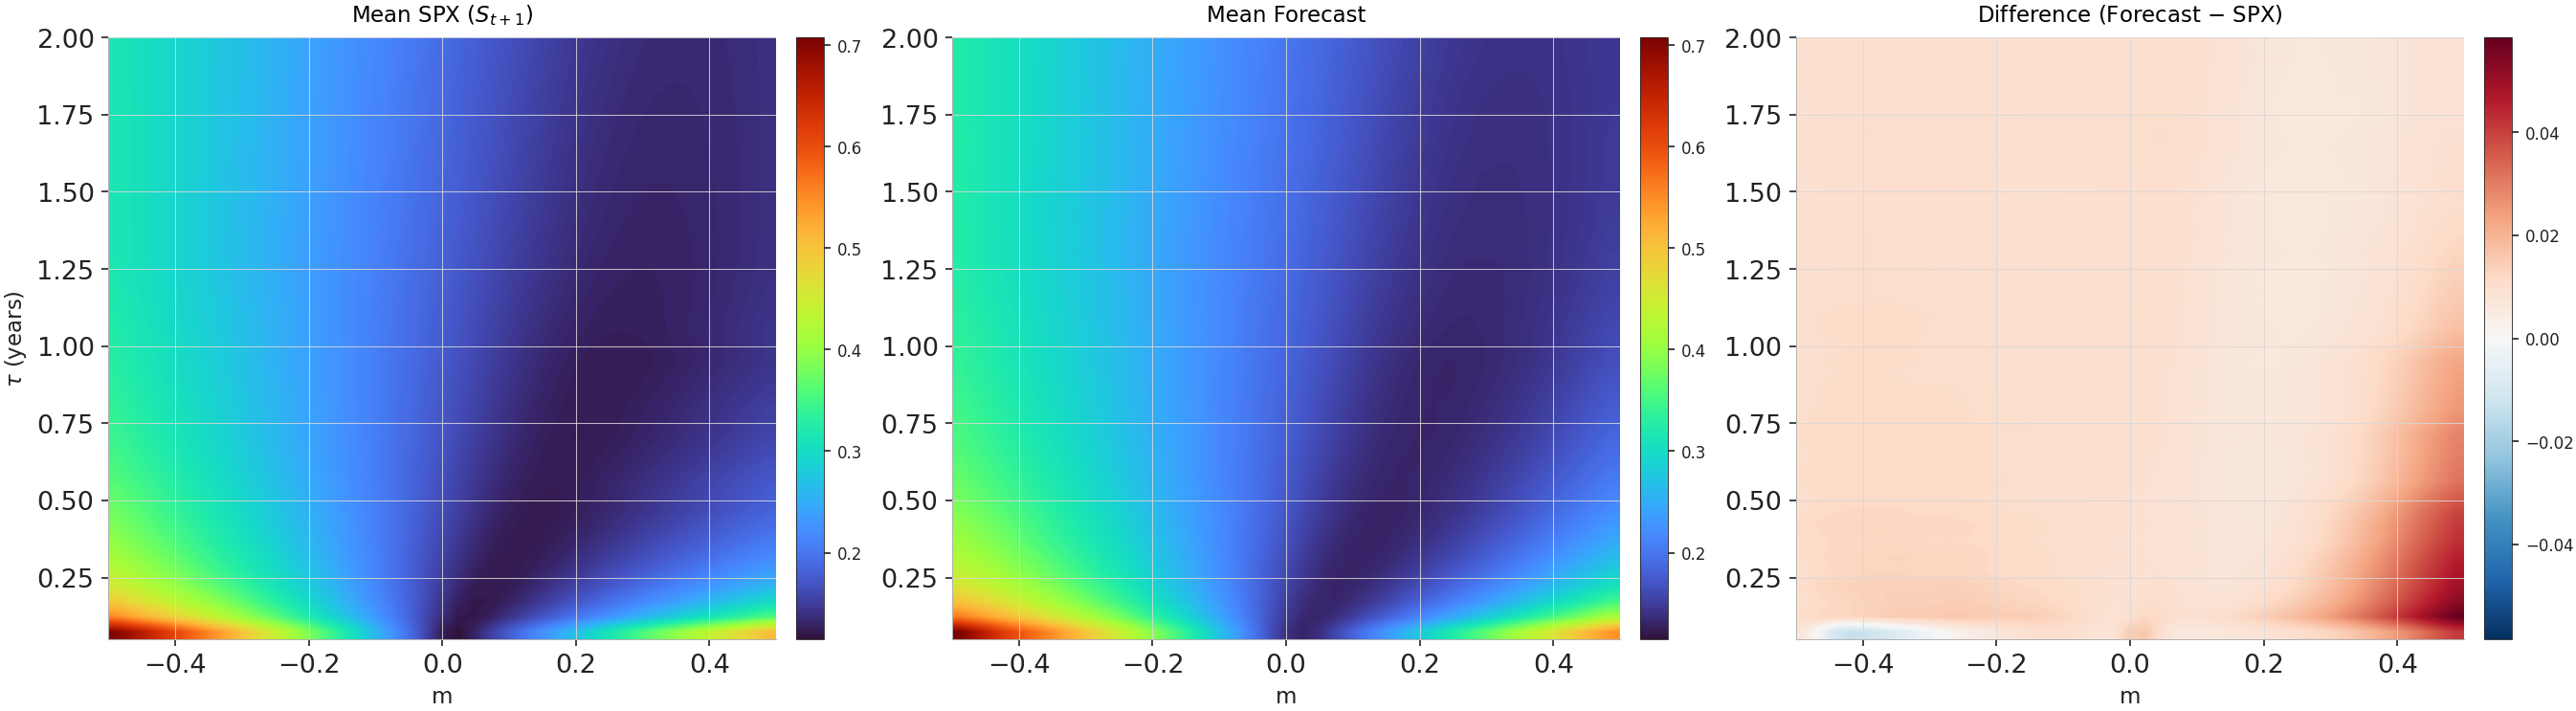

In [16]:
_hist_insts = [inst for inst in instances if inst["path_type"] == "historical"]
if not _hist_insts:
    print("No historical instances available — skipping mean heatmap.")
else:
    _gt_stack = np.stack([inst["ground_truth"] for inst in _hist_insts], axis=0)
    _fc_stack = np.stack([inst["forecast"] for inst in _hist_insts], axis=0)
    _mean_gt = np.nanmean(_gt_stack, axis=0)
    _mean_fc = np.nanmean(_fc_stack, axis=0)
    _mean_diff = _mean_fc - _mean_gt

    _m_ax = np.asarray(GRID.log_moneyness, dtype=np.float64)
    _tau_ax = np.asarray(GRID.tau, dtype=np.float64)

    _shared_vmin = min(float(np.nanmin(_mean_gt)), float(np.nanmin(_mean_fc)))
    _shared_vmax = max(float(np.nanmax(_mean_gt)), float(np.nanmax(_mean_fc)))
    if (not np.isfinite(_shared_vmin)) or (not np.isfinite(_shared_vmax)) or _shared_vmin == _shared_vmax:
        _shared_vmin, _shared_vmax = 0.0, 1.0

    _diff_abs = float(np.nanmax(np.abs(_mean_diff)))
    if not np.isfinite(_diff_abs) or _diff_abs == 0.0:
        _diff_abs = 1.0

    _panels = [
        (_mean_gt, r"Mean SPX ($S_{t+1}$)", SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
        (_mean_fc, "Mean Forecast", SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
        (_mean_diff, r"Difference (Forecast $-$ SPX)", DIFF_CMAP, r"$\Delta\sigma$", True),
    ]

    with rc_context():
        fig_mean, axes_mean = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
        fig_mean.patch.set_facecolor(plt.rcParams["figure.facecolor"])

        for col, (mat, ttl, cmap, cbar_label, is_diff) in enumerate(_panels):
            ax = axes_mean[col]
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color("0.7")
                spine.set_linewidth(0.5)

            if is_diff:
                _vmin, _vmax = -_diff_abs, _diff_abs
            else:
                _vmin, _vmax = _shared_vmin, _shared_vmax

            image = ax.imshow(
                mat.T,
                origin="lower",
                aspect="auto",
                extent=(_m_ax[0], _m_ax[-1], _tau_ax[0], _tau_ax[-1]),
                cmap=cmap,
                vmin=_vmin,
                vmax=_vmax,
                interpolation="bilinear",
            )
            ax.set_title(ttl, pad=8)
            ax.set_xlabel(r"m")
            ax.set_ylabel(r"$\tau$ (years)" if col == 0 else "")
            ax.tick_params(direction="out")
            style_2d_axes(ax)

            cbar = fig_mean.colorbar(image, ax=ax, fraction=0.046, pad=0.03, aspect=22)
            cbar.ax.tick_params(labelsize=8)
            cbar.outline.set_linewidth(0.4)

        fig_mean.savefig(
            "trans_validation_mean_historical_vs_forecast_heatmap.pdf",
            format="pdf",
            bbox_inches="tight",
        )
        plt.show()

## Mean smile cross-section (historical)

IV smile slices at $\tau \in \{0.05,\,1.05,\,2.0\}$ years comparing the mean realized SPX surface ($S_{t+1}$) to the mean repaired forecast across historical validation instances.

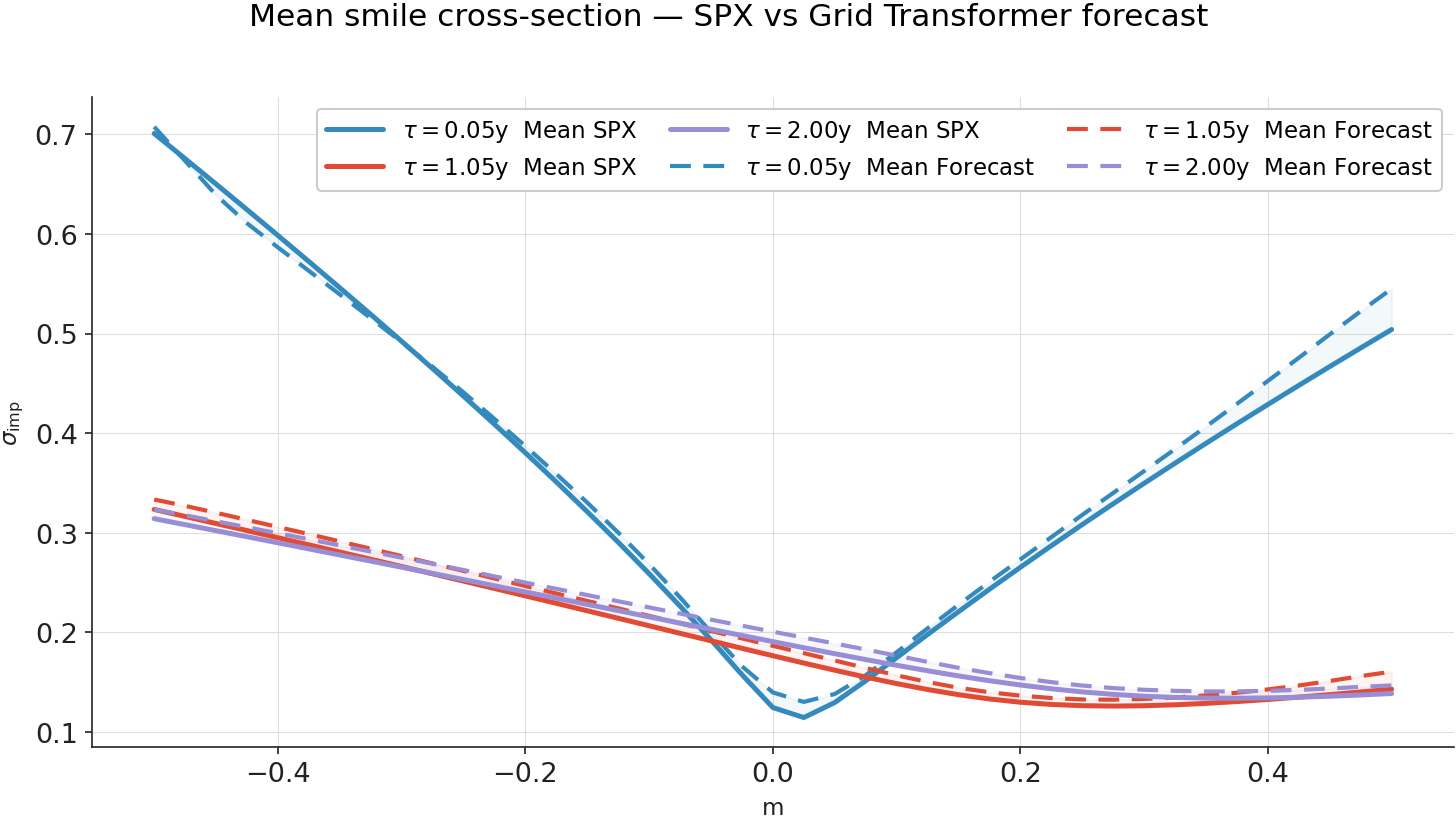

In [17]:
SMILE_TAU_YEARS = (0.05, 1.05, 2.0)

_hist_insts = [inst for inst in instances if inst["path_type"] == "historical"]
if not _hist_insts:
    print("No historical instances available — skipping mean smile cross-section.")
else:
    _gt_stack = np.stack([inst["ground_truth"] for inst in _hist_insts], axis=0)
    _fc_stack = np.stack([inst["forecast"] for inst in _hist_insts], axis=0)
    _mean_gt = np.nanmean(_gt_stack, axis=0)
    _mean_fc = np.nanmean(_fc_stack, axis=0)

    _tau_ax = np.asarray(GRID.tau, dtype=np.float64)
    _m_ax = np.asarray(GRID.log_moneyness, dtype=np.float64)
    smile_tau_idx = [int(np.argmin(np.abs(_tau_ax - t))) for t in SMILE_TAU_YEARS]

    with rc_context():
        fig_smile, ax = plt.subplots(figsize=(10, 5.5))
        fig_smile.patch.set_facecolor(plt.rcParams["figure.facecolor"])

        for j, tidx in enumerate(smile_tau_idx):
            color = TENOR_COLORS[j % len(TENOR_COLORS)]
            tenor_label = rf"$\tau = {_tau_ax[tidx]:.2f}$y"
            ax.plot(
                _m_ax,
                _mean_gt[:, tidx],
                color=color,
                lw=2.4,
                solid_capstyle="round",
                label=f"{tenor_label}  Mean SPX",
            )
            ax.plot(
                _m_ax,
                _mean_fc[:, tidx],
                color=color,
                lw=2.0,
                ls="--",
                dashes=(5, 3),
                label=f"{tenor_label}  Mean Forecast",
            )
            ax.fill_between(_m_ax, _mean_gt[:, tidx], _mean_fc[:, tidx], color=color, alpha=0.06)

        rmse = float(np.sqrt(np.nanmean((_mean_fc - _mean_gt) ** 2)))

        ax.set_xlabel("m")
        ax.set_ylabel(r"$\sigma_{\mathrm{imp}}$")
        style_2d_axes(ax)

        handles, labels = ax.get_legend_handles_labels()
        ncol = min(len(SMILE_TAU_YEARS), 5)
        gt_handles = handles[0::2]
        fc_handles = handles[1::2]
        gt_labels = labels[0::2]
        fc_labels = labels[1::2]
        ax.legend(
            gt_handles + fc_handles,
            gt_labels + fc_labels,
            ncols=ncol,
            loc="upper right",
            handlelength=2.5,
            columnspacing=1.4,
        )

        fig_smile.suptitle(
            "Mean smile cross-section — SPX vs Grid Transformer forecast",
            fontsize=15,
            y=1.02,
        )
        fig_smile.tight_layout()
        fig_smile.savefig(
            "trans_validation_mean_smile_cross_section.pdf",
            format="pdf",
            bbox_inches="tight",
        )
        plt.show()